# Зависимость косинусного расстояния в PCA от перцептивных расстояний

LM Embed shape(1755, 3584)
LM PCA 99-comp shape(1755, 33)
VL Embed shape(1755, 3584)
VL PCA 99-comp shape(1755, 19)


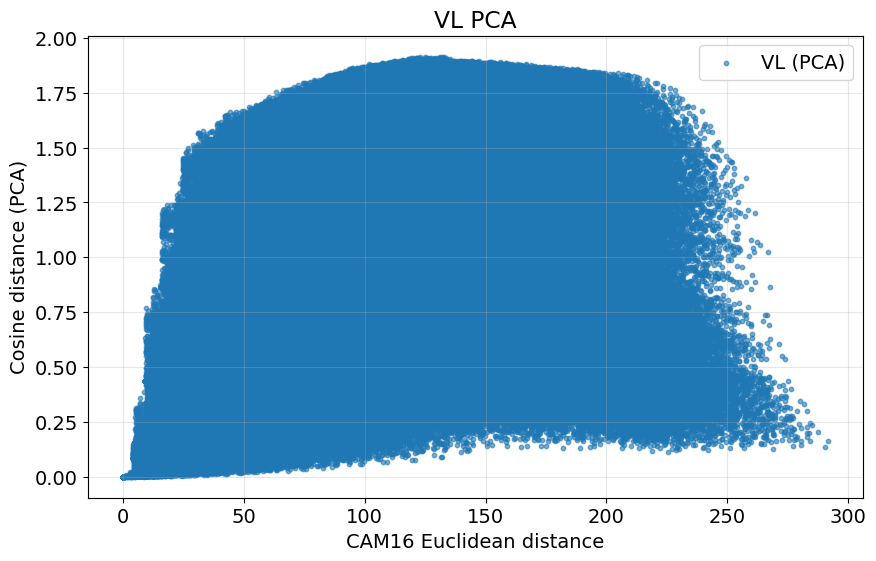

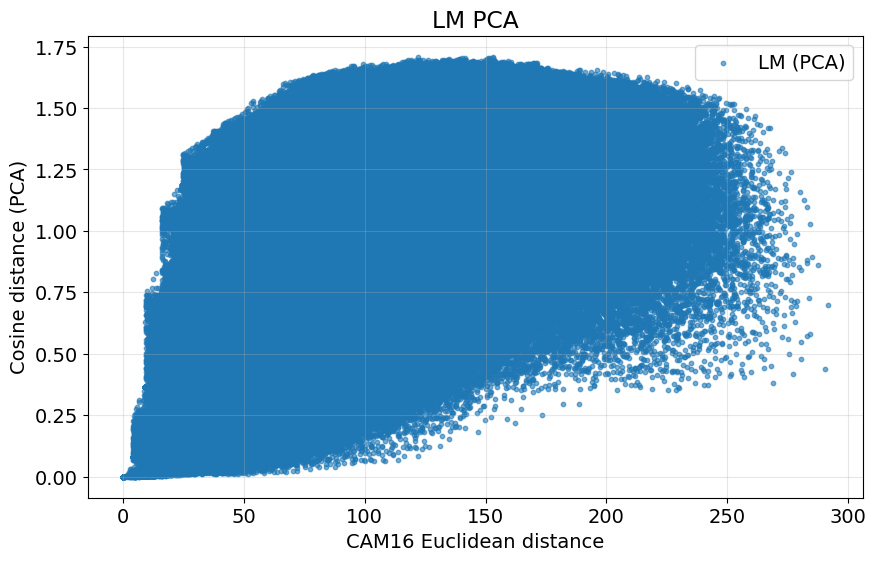

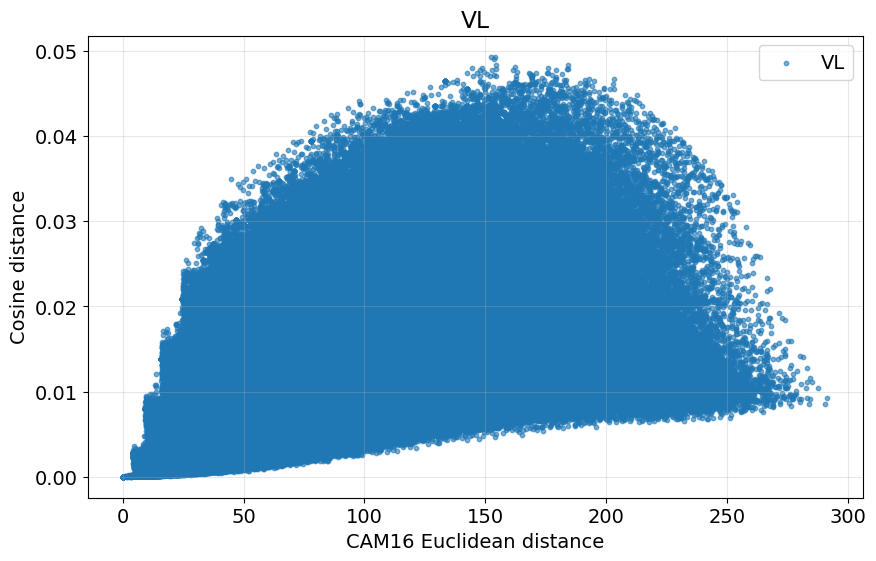

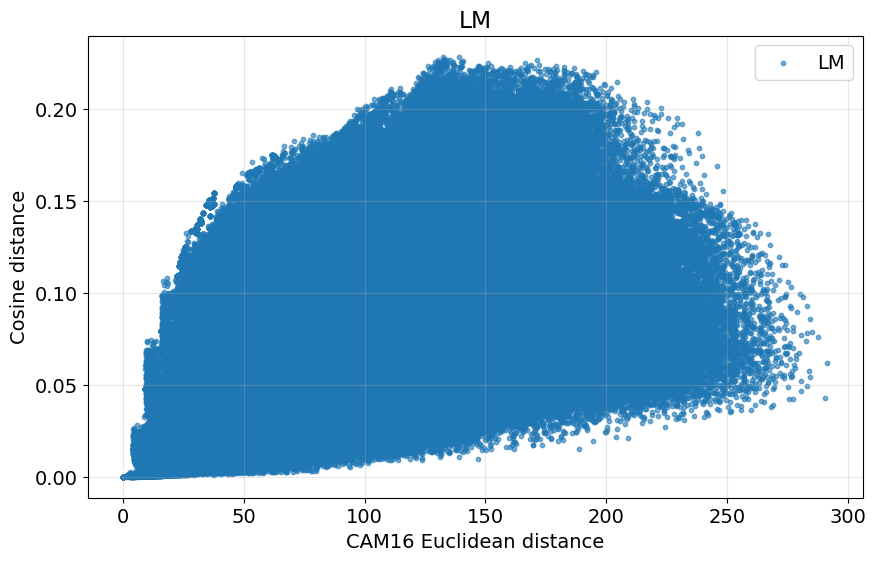

In [1]:
from scipy.spatial.distance import cosine
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer

analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe', 'data/colors/munsell_colors/munsell_manifest.csv')
all_data = analyzer.chain_loader.get_all_available_embeddings()
lm = all_data["lm_pooled"]
vl = all_data["vl_pooled"]
meta = all_data["metadata"] 

pca_result = analyzer.pca_by_embeddings(all_data)
n_components_99_lm = pca_result["lm_pooled"]['n_components_99']
n_components_99_vl = pca_result["vl_pooled"]['n_components_99']

pca_lm = pca_result["lm_pooled"]["pca_result"][:, :n_components_99_lm]
pca_vl = pca_result["vl_pooled"]["pca_result"][:, :n_components_99_vl]

print(f"LM Embed shape{lm.shape}")
print(f"LM PCA 99-comp shape{pca_lm.shape}")

print(f"VL Embed shape{vl.shape}")
print(f"VL PCA 99-comp shape{pca_vl.shape}")

colors_xyY = np.array([
    [item['xyY']['x'], item['xyY']['y'], item['xyY']['Y']]
    for item in meta.values()
], dtype=float)
colors_rgb = np.array([
    [item['RGB']['R'], item['RGB']['G'], item['RGB']['B']]
    for item in meta.values()
], dtype=float)
cam = [XYZ_to_CAM16LCD(xyY_to_XYZ(x)) for x in colors_xyY]

lm_cos_pca = pairwise_distances(pca_lm, metric='cosine')  
vl_cos_pca = pairwise_distances(pca_vl, metric='cosine')   
lm_cos = pairwise_distances(lm, metric='cosine')   
vl_cos = pairwise_distances(vl, metric='cosine')   
cam_dist = pairwise_distances(cam, metric='euclidean') 


# График: косинусное расстояние (PCA) vs CAM для выбранного цета i0
# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], vl_cos_pca[i0], s=30, alpha=0.7, label="VL (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()

# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], lm_cos_pca[i0], s=30, alpha=0.7, label="LM (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()


tri = np.triu_indices_from(cam_dist, k=1)

# График: сравнение косинусное расстояние vs CAM для исходных эмбедов и после pca 
# plt.figure(figsize=(10, 6))
# plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
# plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
# plt.xlabel("CAM16 Euclidean distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend()
# plt.title('VL/LM PCA')
# plt.grid(True, alpha=0.3)
# plt.show()


###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('VL PCA')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos_pca[tri], s=10, alpha=0.6, label="LM (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('LM PCA')
plt.grid(True, alpha=0.3)
plt.show()

###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('VL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos[tri], s=10, alpha=0.6, label="LM")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('LM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [2]:
from scipy.stats import spearmanr, pearsonr

x = cam_dist[tri]          
y_vl = vl_cos[tri]
y_vl_pca = vl_cos_pca[tri]
y_lm = lm_cos[tri]
y_lm_pca = lm_cos_pca[tri]

def corr_report(name, y):
    sp = spearmanr(x, y).correlation
    pr = pearsonr(x, y).statistic
    print(f"{name:10s} | Spearman ρ={sp:.4f} | Pearson r={pr:.4f}")

corr_report("VL", y_vl)
corr_report("VL_PCA", y_vl_pca)
corr_report("LM", y_lm)
corr_report("LM_PCA", y_lm_pca)


VL         | Spearman ρ=0.6081 | Pearson r=0.5288
VL_PCA     | Spearman ρ=0.5494 | Pearson r=0.5089
LM         | Spearman ρ=0.5596 | Pearson r=0.5157
LM_PCA     | Spearman ρ=0.5967 | Pearson r=0.5864


In [3]:
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import root_mean_squared_error, r2_score
# from scipy.stats import pearsonr

# #  метрики
# def metrics_for_reg(X, y, name):
#     X = np.asarray(X)
#     y = np.asarray(y)
#     Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
#     reg = LinearRegression().fit(Xtr, ytr)
#     def _flat_corr(y_true, y_pred):
#         a, b = y_true.reshape(-1), y_pred.reshape(-1)
#         return pearsonr(a, b)[0]
#     ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
#     metrics = {
#         "rmse_train": root_mean_squared_error(ytr, ytr_pred),
#         "rmse_test":  root_mean_squared_error(yte, yte_pred),
#         "r2_train":   r2_score(ytr, ytr_pred, multioutput='variance_weighted'),
#         "r2_test":    r2_score(yte, yte_pred, multioutput='variance_weighted'),
#         "corr_train": _flat_corr(ytr, ytr_pred),
#         "corr_test":  _flat_corr(yte, yte_pred),
#         "reg": reg
#     }
#     print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f} / {metrics['rmse_test']:.4f} | "
#           f"R2: {metrics['r2_train']:.4f} / {metrics['r2_test']:.4f} | "
#           f"Corr: {metrics['corr_train']:.4f} / {metrics['corr_test']:.4f}")
#     return metrics

# m_lm = metrics_for_reg(lm, cam, "LM")
# m_vl = metrics_for_reg(vl, cam, "VL")
# reg_lm, reg_vl = m_lm["reg"], m_vl["reg"]

# # коэффициенты для лк
# weights_list = [(0.5, 0.5), (0.33, 0.66), (0.66, 0.33)]

# def sample_mixes_with_cam(embeds, cam_full, weights_list, n_pairs=200, seed=0):
#     rng = np.random.default_rng(seed)
#     cam_arr = np.asarray(cam_full, dtype=float)
#     mixes_emb, mixes_cam_true, labels = [], [], []
#     for w in weights_list:
#         idx = rng.integers(0, len(embeds), size=(n_pairs, 2))
#         a_emb, b_emb = embeds[idx[:, 0]], embeds[idx[:, 1]]
#         a_cam, b_cam = cam_arr[idx[:, 0]], cam_arr[idx[:, 1]]
#         mixes_emb.append(w[0] * a_emb + w[1] * b_emb)
#         mixes_cam_true.append(w[0] * a_cam + w[1] * b_cam)
#         labels.extend([tuple(w)] * n_pairs)
#     return np.vstack(mixes_emb), np.vstack(mixes_cam_true), np.array(labels)

# def plot_pred_vs_true(mix_emb, mix_cam_true, reg, labels, title):
#     mix_cam_pred = reg.predict(mix_emb)
#     pred_dist = pairwise_distances(mix_cam_pred, metric="euclidean")
#     true_dist = pairwise_distances(mix_cam_true, metric="euclidean")
#     tri = np.triu_indices_from(pred_dist, k=1)

#     uniq_w = {w: i for i, w in enumerate(sorted(set(map(tuple, labels))))}
#     colors = np.array([uniq_w[tuple(w)] for w in labels])

#     plt.figure(figsize=(9, 6))
#     plt.scatter(true_dist[tri], pred_dist[tri],
#                 c=colors[tri[0]], cmap="tab10", s=10, alpha=0.6)
#     plt.xlabel("True CAM distance (linear mixes)")
#     plt.ylabel("Predicted CAM distance (via regressor)")
#     plt.title(title)
#     cbar = plt.colorbar()
#     cbar.set_ticks(list(uniq_w.values()))
#     cbar.set_ticklabels([str(k) for k in uniq_w.keys()])
#     plt.grid(True, alpha=0.3)
#     plt.show()

# def metrics_on_mixes(mix_cam_true, mix_cam_pred, name):
#     def _flat_corr(y_true, y_pred):
#         a = np.asarray(y_true).reshape(-1)
#         b = np.asarray(y_pred).reshape(-1)
#         return pearsonr(a, b)[0]
#     pred_dist = pairwise_distances(mix_cam_pred, metric="euclidean")
#     true_dist = pairwise_distances(mix_cam_true, metric="euclidean")
#     rmse = root_mean_squared_error(true_dist, pred_dist)
#     r2 = r2_score(true_dist, pred_dist, multioutput="variance_weighted")
#     corr = _flat_corr(true_dist, pred_dist)
#     # rmse = root_mean_squared_error(mix_cam_true, mix_cam_pred)
#     # r2 = r2_score(mix_cam_true, mix_cam_pred, multioutput="variance_weighted")
#     # corr = _flat_corr(mix_cam_true, mix_cam_pred)
#     print(f"[{name} mixes] RMSE: {rmse:.4f} | R2: {r2:.4f} | Corr: {corr:.4f}")
#     return {"rmse": rmse, "r2": r2, "corr": corr}

# # LM
# mix_emb_lm, mix_cam_true_lm, labels_lm = sample_mixes_with_cam(lm, cam, weights_list, n_pairs=200, seed=1)
# plot_pred_vs_true(mix_emb_lm, mix_cam_true_lm, reg_lm, labels_lm,
#                   "LM mixes: predicted vs true CAM distances")

# metrics_on_mixes(mix_cam_true_lm, mix_cam_pred_lm, "LM")
# # VL
# mix_emb_vl, mix_cam_true_vl, labels_vl = sample_mixes_with_cam(vl, cam, weights_list, n_pairs=200, seed=1)
# plot_pred_vs_true(mix_emb_vl, mix_cam_true_vl, reg_vl, labels_vl,
#                   "VL mixes: predicted vs true CAM distances")

# metrics_on_mixes(mix_cam_true_vl, mix_cam_pred_vl, "VL")


# Проверка корретности обучения на эмбедингах VLM для предсказания cam координат

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import pearsonr

X_base = np.asarray(colors_rgb, dtype=float)
Y = np.asarray(cam, dtype=float)
target_features = 1000


def make_rootpoly(rgb, total_feats=33, seed=0):
    """
    Генерирует total_feats признаков: первые 3 — исходные r,g,b,
    остальные — случайные произвежения r^a * g^b * b^c, a+b+c=1.
    """
    assert total_feats >= 3
    rng = np.random.default_rng(seed)
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    base = np.stack([r, g, b], axis=1)  # (N,3)
    n_extra = total_feats - 3

    exps = rng.dirichlet(np.ones(3), size=n_extra)  # (n_extra,3), сумма = 1
    extra = (r[:, None] ** exps[:, 0]) * (g[:, None] ** exps[:, 1]) * (b[:, None] ** exps[:, 2])  # (N, n_extra)

    return np.hstack([base, extra])  # shape (N, total_feats)


def pad_to_dim(X, target_dim, noise_std=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if d >= target_dim:
        return X[:, :target_dim]
    pad = rng.normal(0, noise_std, size=(n, target_dim - d))
    return np.hstack([X, pad])

# строим варианты
X_rgb = pad_to_dim(X_base, target_features, noise_std=0.0, seed=1)          # дополняем нулями? нет, шум=0 -> нули
X_rootpoly = pad_to_dim(make_rootpoly(X_base, total_feats=2000, seed=1), target_features, seed=2)     # root-poly + шум до 2000
X_noise = pad_to_dim(X_base, target_features, noise_std=0.05, seed=3)       # RGB + шум до 2000

def eval_reg(X, y, name):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    reg = LinearRegression().fit(Xtr, ytr)
    ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]
    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
    )
    print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics, reg

lm  = np.asarray(lm,  dtype=float)
vl  = np.asarray(vl,  dtype=float)
lm_pca  = np.asarray(pca_lm,  dtype=float)
vl_pca  = np.asarray(pca_vl,  dtype=float)
cam = np.asarray(cam, dtype=float)

print("----Linear Regression----")
m_lm_pca, reg_lm = eval_reg(lm_pca, cam, "lm_pca")
m_vl_pca, reg_vl = eval_reg(vl_pca, cam, "vl_pca")
m_lm, reg_lm = eval_reg(lm, cam, "lm")
m_vl, reg_vl = eval_reg(vl, cam, "vl")
m_rgb, reg_rgb         = eval_reg(X_base,      Y, "RGB")
m_rootpoly, reg_rp     = eval_reg(X_rootpoly, Y, "Root-poly (33) + noise to 2000")
m_noise, reg_noise     = eval_reg(X_noise,    Y, "RGB + noise to 2000")


----Linear Regression----
[lm_pca] RMSE train/test: 4.1781/3.7989 | R2: 0.9896/0.9910 | Corr: 0.9989/0.9990
[vl_pca] RMSE train/test: 4.9135/4.6248 | R2: 0.9859/0.9870 | Corr: 0.9985/0.9986
[lm] RMSE train/test: 0.0000/1.0711 | R2: 1.0000/0.9993 | Corr: 1.0000/0.9999
[vl] RMSE train/test: 0.0000/1.3655 | R2: 1.0000/0.9990 | Corr: 1.0000/0.9999
[RGB] RMSE train/test: 11.5913/11.5928 | R2: 0.9290/0.9261 | Corr: 0.9924/0.9921
[Root-poly (33) + noise to 2000] RMSE train/test: 8.8014/119.1882 | R2: 0.9581/-8.6444 | Corr: 0.9955/0.6023
[RGB + noise to 2000] RMSE train/test: 6.0709/21.3521 | R2: 0.9806/0.7500 | Corr: 0.9979/0.9736


In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def eval_mlp(X, y, name, hidden=(512, 256, 128), lr=1e-3, max_iter=500, seed=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=lr,
            max_iter=max_iter,
            batch_size=128,
            random_state=seed,
            early_stopping=True,
            n_iter_no_change=20,
            verbose=False,
        )
    )
    mlp.fit(Xtr, ytr)

    ytr_pred, yte_pred = mlp.predict(Xtr), mlp.predict(Xte)

    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
        model      = mlp,
    )
    print(f"[MLP {name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics

# Сравнение результатов обучения MLP
mlp_lm     = eval_mlp(lm,      cam, "lm")
mlp_vl     = eval_mlp(vl,      cam, "vl")
mlp_lm_pca = eval_mlp(lm_pca,  cam, "lm_pca")
mlp_vl_pca = eval_mlp(vl_pca,  cam, "vl_pca")
mlp_lm_pca = eval_mlp(X_base,  Y, "rgb")
mlp_lm_pca = eval_mlp(X_rootpoly,  Y, "root poly")


[MLP lm] RMSE train/test: 0.9215/1.1758 | R2: 0.9996/0.9992 | Corr: 1.0000/0.9999
[MLP vl] RMSE train/test: 0.8562/1.1679 | R2: 0.9996/0.9992 | Corr: 1.0000/0.9999
[MLP lm_pca] RMSE train/test: 1.0370/1.8052 | R2: 0.9994/0.9979 | Corr: 0.9999/0.9998
[MLP vl_pca] RMSE train/test: 1.2335/1.6882 | R2: 0.9991/0.9983 | Corr: 0.9999/0.9998
[MLP rgb] RMSE train/test: 1.4743/1.5350 | R2: 0.9988/0.9987 | Corr: 0.9999/0.9999
[MLP root poly] RMSE train/test: 1.6062/1.7683 | R2: 0.9986/0.9981 | Corr: 0.9998/0.9998


# Обучение отображения A с сохранением расстояния для функции $$\Sigma_{i,j}(||A(x_i-x_j)||^2 - ||y_i-y_j||^2)^2$$

In [6]:
lm.shape, vl.shape

((1755, 3584), (1755, 3584))

LM layer: R² = 0.9996, RMSE = 0.9007
LM layer:
  Rmse(dist_true, dist_pred) = 0.6505
  Pearson(dist_true, dist_pred) = 0.9998 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9998 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5157 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.5596 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5159 (p = 0.00e+00)


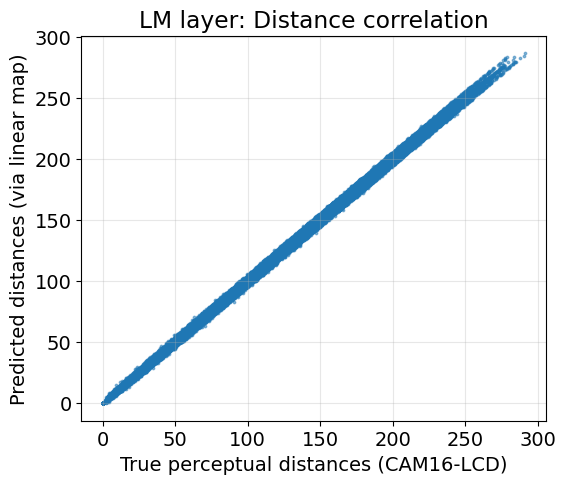

LM layer: Matrix W shape = (3, 3584), Bias b shape = (3,)
Vision layer: R² = 0.9989, RMSE = 1.4438
Vision layer:
  Rmse(dist_true, dist_pred) = 5.1965
  Pearson(dist_true, dist_pred) = 0.9986 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9986 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5288 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.6081 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5277 (p = 0.00e+00)


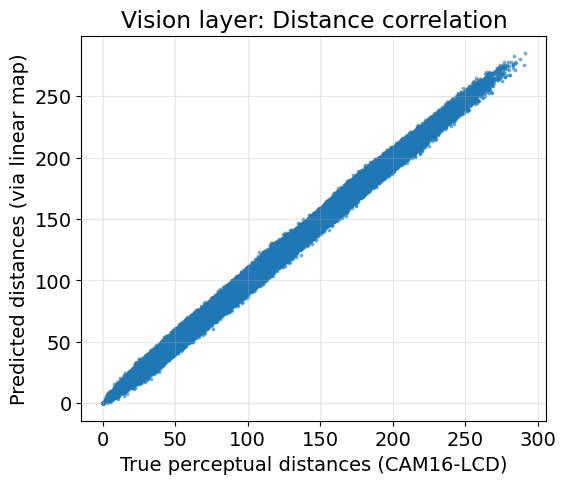

Vision layer: Matrix W shape = (3, 3584), Bias b shape = (3,)
Correlation between LM and Vision predicted colors:
  Pearson = 0.9999
  Spearman = 0.9998


In [7]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, pairwise_distances
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

def linear_color_mapping(embeddings, colors_cam, layer_name="LM"):
    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, colors_cam, test_size=0.2, random_state=42
    )

    # Линейное отображение
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred_test = reg.predict(X_test)
    y_pred_all = reg.predict(embeddings)

    # Оценка точности
    r2 = r2_score(y_test, y_pred_test, multioutput='variance_weighted')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"{layer_name} layer: R² = {r2:.4f}, RMSE = {rmse:.4f}")

    # Глобальный анализ через pairwise distances
    D_emb = pairwise_distances(embeddings, metric='cosine')
    D_true = pairwise_distances(colors_cam, metric='euclidean')
    D_pred = pairwise_distances(y_pred_all, metric='euclidean')

    n = embeddings.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    v_emb = D_emb[triu_idx]
    v_true = D_true[triu_idx]
    v_pred = D_pred[triu_idx]

    # pearson_true_pred = pearsonr(v_true, v_pred)[0]
    # spearman_true_pred = spearmanr(v_true, v_pred).correlation
    # pearson_emb_true = pearsonr(v_emb, v_true)[0]
    # spearman_emb_true = spearmanr(v_emb, v_true)[0]
    # pearson_emb_pred = pearsonr(v_emb, v_pred)[0]


    # print(f"{layer_name} layer:")
    # print(f"  Pearson(dist_true, dist_pred) = {pearson_true_pred:.4f}")
    # print(f"  Spearman(dist_true, dist_pred) = {spearman_true_pred:.4f}")
    # print(f"  Pearson(dist_emb, dist_true)   = {pearson_emb_true:.4f}")
    # print(f"  Spearman(dist_emb, dist_true)   = {spearman_emb_true:.4f}")
    # print(f"  Pearson(dist_emb, dist_pred)   = {pearson_emb_pred:.4f}")

    dist_rmse = mean_squared_error(v_true, v_pred)
    pearson_r, pearson_p = pearsonr(v_true, v_pred)
    spearman_res = spearmanr(v_true, v_pred)
    spearman_r = getattr(spearman_res, 'correlation', spearman_res.statistic)
    spearman_p = spearman_res.pvalue

    emb_true_pr, emb_true_pp = pearsonr(v_emb, v_true)
    emb_true_sr = spearmanr(v_emb, v_true)
    emb_true_sr_r = getattr(emb_true_sr, 'correlation', emb_true_sr.statistic)
    emb_true_sr_p = emb_true_sr.pvalue

    emb_pred_pr, emb_pred_pp = pearsonr(v_emb, v_pred)

    print(f"{layer_name} layer:")
    print(f"  Rmse(dist_true, dist_pred) = {dist_rmse:.4f}")
    print(f"  Pearson(dist_true, dist_pred) = {pearson_r:.4f} (p = {pearson_p:.2e})")
    print(f"  Spearman(dist_true, dist_pred) = {spearman_r:.4f} (p = {spearman_p:.2e})")
    print(f"  Pearson(dist_emb, dist_true)   = {emb_true_pr:.4f} (p = {emb_true_pp:.2e})")
    print(f"  Spearman(dist_emb, dist_true)  = {emb_true_sr_r:.4f} (p = {emb_true_sr_p:.2e})")
    print(f"  Pearson(dist_emb, dist_pred)   = {emb_pred_pr:.4f} (p = {emb_pred_pp:.2e})")


    # Визуализация согласованности расстояний
    plt.figure(figsize=(6,5))
    plt.scatter(v_true, v_pred, s=3, alpha=0.5)
    plt.xlabel('True perceptual distances (CAM16-LCD)')
    plt.ylabel('Predicted distances (via linear map)')
    plt.title(f'{layer_name} layer: Distance correlation')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Матрица линейного преобразования и bias
    W = reg.coef_
    b = reg.intercept_
    print(f"{layer_name} layer: Matrix W shape = {W.shape}, Bias b shape = {b.shape}")

    return y_pred_all, W, b

# === LM layer ===
y_pred_lm, W_lm, b_lm = linear_color_mapping(lm, cam, layer_name="LM")

# === Vision layer ===
y_pred_vl, W_vl, b_vl = linear_color_mapping(vl, cam, layer_name="Vision")

# === Корреляция между предсказанными цветами двух слоёв ===
pearson_between_layers = pearsonr(
    y_pred_lm.flatten(), y_pred_vl.flatten()
)[0]
spearman_between_layers = spearmanr(
    y_pred_lm.flatten(), y_pred_vl.flatten()
).correlation

print(f"Correlation between LM and Vision predicted colors:")
print(f"  Pearson = {pearson_between_layers:.4f}")
print(f"  Spearman = {spearman_between_layers:.4f}")


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

# ============================================================
# 1) Pair sampling utilities for distance-matching objective
# ============================================================

def sample_pairs_uniform(n, n_pairs, seed=42):
    """Uniformly sample (i,j) with i<j."""
    rng = np.random.default_rng(seed)
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    # avoid i==j
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2


def make_pair_batch(X, Y, i, j):
    """
    X: (n,d), Y: (n,3)
    returns:
      V: (B,d)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2
      t :(B,)   = ||Y[i]-Y[j]||
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))
    return V, t2, t

# ============================================================
# 2) Objective: match squared distances via A (A in R^{3xd})
#    L = sum ( ||A v||^2 - t2 )^2
#    grad: dL/dA = 4 * sum e * (A v) v^T
# ============================================================

def loss_and_grad_A_squared(A, V, t2, weights=None):
    """
    A: (3,d)
    V: (B,d)
    t2: (B,)
    weights: (B,) or None

    returns:
      loss (float), gradA (3,d)
    """
    AV = V @ A.T                 # (B,3)   (note: V @ A.T = (A V^T)^T
    s = np.sum(AV * AV, axis=1)  # (B,) squared norms ||A v||^2
    e = (s - t2)                 # (B,)

    if weights is not None:
        w = weights
        loss = np.mean(w * (e * e))
        # grad = 4 * mean( w * e * (A v) v^T )
        # compute per-sample coeff c = 4*w*e
        c = 4.0 * w * e                          # (B,)
    else:
        loss = np.mean(e * e)
        c = 4.0 * e

    # gradA = mean over batch of c_p * (A v_p) v_p^T
    # AV = (B,3), V = (B,d)
    # We want sum_p c_p * outer(AV[p], V[p])  -> (3,d)
    grad = ( (c[:, None] * AV).T @ V ) / V.shape[0]   # (3,d)

    return float(loss), grad

def fit_A_with_normalization(
    X, Y_cam, W_init=None,
    n_pairs=500_000,
    batch_size=2048,
    n_steps=3000,
    lr=1e-3,
    seed=42,
    verbose_every=200,
    grad_clip=10.0,
):
    """
    Версия с правильной нормализацией данных
    """
    rng = np.random.default_rng(seed)
    n, d = X.shape
    
    # === 1. Нормализация X ===
    scaler_X = StandardScaler()
    X_norm = scaler_X.fit_transform(X)
    
    # === 2. Нормализация Y (важно для t²!) ===
    scaler_Y = StandardScaler()
    Y_norm = scaler_Y.fit_transform(Y_cam)
    
    print(f"После нормализации:")
    print(f"  X_norm: range=[{X_norm.min():.2f}, {X_norm.max():.2f}], std={X_norm.std():.4f}")
    print(f"  Y_norm: range=[{Y_norm.min():.2f}, {Y_norm.max():.2f}], std={Y_norm.std():.4f}")
    
    # Проверяем t² после нормализации
    i_test, j_test = sample_pairs_uniform(n, 5000, seed=0)
    _, t2_test, _ = make_pair_batch(X_norm, Y_norm, i_test, j_test)
    print(f"  t² после норм.: min={t2_test.min():.2f}, max={t2_test.max():.2f}, mean={t2_test.mean():.2f}")
    
    # === 3. Инициализация A ===
    if W_init is not None:
        # Трансформируем W с учётом нормализации
        # Исходно: y = W @ x + b
        # После норм: y_norm = (y - μ_y) / σ_y = (W @ x + b - μ_y) / σ_y
        #           x_norm = (x - μ_x) / σ_x  =>  x = x_norm * σ_x + μ_x
        # y_norm = (W @ (x_norm * σ_x + μ_x) + b - μ_y) / σ_y
        #        = (W @ x_norm * σ_x) / σ_y + const
        # => A_norm = diag(1/σ_y) @ W @ diag(σ_x)
        
        sigma_x = scaler_X.scale_  # (d,)
        sigma_y = scaler_Y.scale_  # (3,)
        
        A = (W_init * sigma_x[None, :]) / sigma_y[:, None]
        print(f"  A init from W: ||A||={np.linalg.norm(A):.4f}")
    else:
        # Xavier init
        A = np.sqrt(2.0 / (d + 3)) * rng.standard_normal((3, d))
        print(f"  A random init: ||A||={np.linalg.norm(A):.4f}")
    
    # === 4. Обучение ===
    i_all, j_all = sample_pairs_uniform(n, n_pairs, seed=seed)
    n_batches = int(np.ceil(n_pairs / batch_size))
    
    for step in range(n_steps):
        b_idx = step % n_batches
        sl = slice(b_idx * batch_size, min((b_idx + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]
        V, t2, _ = make_pair_batch(X_norm, Y_norm, i, j)
        
        loss, grad = loss_and_grad_A_squared(A, V, t2)
        
        # Gradient clipping
        gnorm = np.linalg.norm(grad)
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / gnorm)
        
        # Check for NaN
        if np.isnan(loss):
            print(f"NaN at step {step}! ||A||={np.linalg.norm(A):.2e}, ||grad||={gnorm:.2e}")
            break
        
        A = A - lr * grad
        
        if (step + 1) % verbose_every == 0:
            print(f"step={step+1}/{n_steps} loss={loss:.6f} ||grad||={gnorm:.4f} ||A||={np.linalg.norm(A):.4f}")
    
    # === 5. Преобразуем A обратно в исходный масштаб ===
    # A_orig такое что: y = A_orig @ x (в исходных координатах, без bias)
    # y_norm = A @ x_norm
    # (y - μ_y)/σ_y = A @ (x - μ_x)/σ_x
    # y = σ_y * A @ (x - μ_x)/σ_x + μ_y
    # y = (σ_y[:, None] * A / σ_x[None, :]) @ x + (μ_y - σ_y * A @ μ_x / σ_x)
    
    sigma_x = scaler_X.scale_
    sigma_y = scaler_Y.scale_
    mu_x = scaler_X.mean_
    mu_y = scaler_Y.mean_
    
    A_orig = (sigma_y[:, None] * A) / sigma_x[None, :]
    b_orig = mu_y - A_orig @ mu_x
    
    return A, A_orig, b_orig, scaler_X, scaler_Y


def evaluate_with_normalization(X, Y_cam, A_norm, scaler_X, scaler_Y, 
                                n_eval_pairs=200_000, seed=0, title=""):
    """Оценка на нормализованных данных"""
    X_norm = scaler_X.transform(X)
    Y_norm = scaler_Y.transform(Y_cam)
    
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, seed=seed)
    V, t2, t = make_pair_batch(X_norm, Y_norm, i, j)
    
    AV = V @ A_norm.T
    s = np.sum(AV * AV, axis=1)
    pred = np.sqrt(np.maximum(s, 0.0))
    
    rmse = np.sqrt(mean_squared_error(t, pred))
    pr, _ = pearsonr(t, pred)
    sr = spearmanr(t, pred)
    sr_r = getattr(sr, 'correlation', sr.statistic)
    
    print(f"\n{title}")
    print(f"  RMSE (normalized) = {rmse:.4f}")
    print(f"  Pearson  = {pr:.4f}")
    print(f"  Spearman = {sr_r:.4f}")
    
    # Также в исходном масштабе
    Y_pred_norm = X_norm @ A_norm.T
    Y_pred = scaler_Y.inverse_transform(Y_pred_norm)
    
    D_true = np.sqrt(np.sum((Y_cam[i] - Y_cam[j])**2, axis=1))
    D_pred = np.sqrt(np.sum((Y_pred[i] - Y_pred[j])**2, axis=1))
    
    rmse_orig = np.sqrt(mean_squared_error(D_true, D_pred))
    pr_orig, _ = pearsonr(D_true, D_pred)
    
    print(f"  RMSE (original scale) = {rmse_orig:.4f}")
    print(f"  Pearson (original)    = {pr_orig:.4f}")
    
    return {"rmse_norm": rmse, "rmse_orig": rmse_orig, "pearson": pr, "spearman": sr_r}


# ============================================================
# Полный эксперимент
# ============================================================

def run_full_experiment(embeddings, Y_cam, layer_name="LM"):
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score

    # Baseline Ridge regression
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, Y_cam, test_size=0.2, random_state=42
    )
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    W = reg.coef_
    b = reg.intercept_
    
    D_pred = pairwise_distances(y_pred, metric='euclidean')
    D_true = pairwise_distances(y_test, metric='euclidean')
    dist_rmse = np.sqrt(mean_squared_error(D_pred, D_true))

    r2 = r2_score(y_test, reg.predict(X_test), multioutput='variance_weighted')
    rmse = np.sqrt(mean_squared_error(y_test, reg.predict(X_test)))
    print(f"{layer_name}: Ridge R² = {r2:.4f}, rmse: {rmse:.2f}, dist_rmse: {dist_rmse:.4f}")
    
    # === Method: Init from W ===
    print(f"\n{'='*50}")
    print(f"Method: Init from W (Ridge)")
    print(f"{'='*50}")
    
    A2_norm, A2_orig, b2_orig, sc_X, sc_Y = fit_A_with_normalization(
        embeddings, Y_cam, W_init=W,
        n_pairs=500_000,
        batch_size=2048,
        n_steps=2000,
        lr=1e-4,  
        grad_clip=5.0,
        verbose_every=400
    )
    res2 = evaluate_with_normalization(embeddings, Y_cam, A2_norm, sc_X, sc_Y,
                                       title=f"{layer_name} | Init from W")
    
    # === Baseline W evaluation ===
    print(f"\n{'='*50}")
    print(f"Baseline W (Ridge) for comparison")
    print(f"{'='*50}")
    
    # Трансформируем W в нормализованное пространство для честного сравнения
    sigma_x = sc_X.scale_
    sigma_y = sc_Y.scale_
    W_norm = (W * sigma_x[None, :]) / sigma_y[:, None]
    
    res_base = evaluate_with_normalization(embeddings, Y_cam, W_norm, sc_X, sc_Y,
                                           title=f"{layer_name} | Baseline W")
    
    return {
        "A_norm": A2_norm, "A2_orig": A2_orig, "res2": res2,
        "W": W, "W_norm": W_norm, "res_baseline": res_base,
        "scaler_X": sc_X, "scaler_Y": sc_Y
    }


# ============================================================
# Запуск
# ============================================================

out_lm = run_full_experiment(lm, cam, layer_name="LM")
# print('\n', '='*100, '\n')
# out_vl = run_full_experiment(vl, cam, layer_name="Vision")


LM: Ridge R² = 0.9996, rmse: 0.90, dist_rmse: 1.4260

Method: Init from W (Ridge)
После нормализации:
  X_norm: range=[-4.93, 4.76], std=1.0000
  Y_norm: range=[-2.91, 2.62], std=1.0000
  t² после норм.: min=0.00, max=33.13, mean=6.08
  A init from W: ||A||=0.9575
step=400/2000 loss=0.011792 ||grad||=23.4247 ||A||=0.9576
step=800/2000 loss=0.011415 ||grad||=23.4896 ||A||=0.9576
step=1200/2000 loss=0.012375 ||grad||=24.6352 ||A||=0.9576
step=1600/2000 loss=0.011939 ||grad||=26.0353 ||A||=0.9577
step=2000/2000 loss=0.013155 ||grad||=25.3752 ||A||=0.9577

LM | Init from W
  RMSE (normalized) = 0.0199
  Pearson  = 0.9998
  Spearman = 0.9998
  RMSE (original scale) = 0.8435
  Pearson (original)    = 0.9998

Baseline W (Ridge) for comparison

LM | Baseline W
  RMSE (normalized) = 0.0181
  Pearson  = 0.9998
  Spearman = 0.9998
  RMSE (original scale) = 0.8036
  Pearson (original)    = 0.9998


In [9]:
# ============================================================
# 1) Pair sampling utilities
# ============================================================

def sample_pairs_uniform(n, n_pairs, seed=42):
    """Uniformly sample (i,j) with i<j."""
    rng = np.random.default_rng(seed)
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    return np.minimum(i, j), np.maximum(i, j)

def make_pair_batch(X, Y, i, j):
    """
    X: (n,d), Y: (n,3)
    returns:
      V: (B,d)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2
      t :(B,)   = ||Y[i]-Y[j]||
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))
    return V, t2, t


# ============================================================
# 2) Squared-distance objective
#    L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared(A, V, t2, weights=None):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)  # ||A v||^2
    e = (s - t2)

    if weights is None:
        loss = np.mean(e * e)
        c = 4.0 * e
    else:
        w = weights
        loss = np.mean(w * (e * e))
        c = 4.0 * w * e

    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])
    return float(loss), grad


# ============================================================
# 3) Evaluation on a FIXED set of pairs (for validation stability)
# ============================================================

def eval_pairs_squared_distance_loss(A, Xn, Yn, i, j):
    V, t2, _ = make_pair_batch(Xn, Yn, i, j)
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)
    e = s - t2
    return float(np.mean(e * e))

def eval_pairs_distance_metrics(A_norm, Xn, Yn, X_orig, Y_orig, scaler_Y, i, j):
    """
    Returns:
      rmse_norm: RMSE on distances in normalized Y space
      pearson_norm/spearman_norm
      rmse_orig: RMSE on distances in original Y space
      pearson_orig/spearman_orig
    """
    # ---- normalized distances ----
    Vn, _, tn = make_pair_batch(Xn, Yn, i, j)
    AV = Vn @ A_norm.T
    pred_n = np.sqrt(np.maximum(np.sum(AV * AV, axis=1), 0.0))

    rmse_norm = float(np.sqrt(mean_squared_error(tn, pred_n)))
    pr_n = float(pearsonr(tn, pred_n)[0])
    sr_n = spearmanr(tn, pred_n)
    sr_n_r = float(getattr(sr_n, "correlation", sr_n.statistic))

    # ---- original-scale distances ----
    # y_pred_norm = A_norm x_norm (no bias), invert scaling to original Y
    Xn_full = Xn
    Y_pred_norm = Xn_full @ A_norm.T
    Y_pred_orig = scaler_Y.inverse_transform(Y_pred_norm)

    D_true = np.sqrt(np.sum((Y_orig[i] - Y_orig[j]) ** 2, axis=1))
    D_pred = np.sqrt(np.sum((Y_pred_orig[i] - Y_pred_orig[j]) ** 2, axis=1))

    rmse_orig = float(np.sqrt(mean_squared_error(D_true, D_pred)))
    pr_o = float(pearsonr(D_true, D_pred)[0])
    sr_o = spearmanr(D_true, D_pred)
    sr_o_r = float(getattr(sr_o, "correlation", sr_o.statistic))

    return {
        "rmse_norm": rmse_norm,
        "pearson_norm": pr_n,
        "spearman_norm": sr_n_r,
        "rmse_orig": rmse_orig,
        "pearson_orig": pr_o,
        "spearman_orig": sr_o_r,
    }


# ============================================================
# 4) Train A WITH validation (object split + fixed val pairs)
# ============================================================

def fit_A_with_normalization_and_validation(
    X_train, Y_train, X_val, Y_val,
    W_init=None,
    n_pairs=500_000,
    batch_size=2048,
    n_steps=2000,
    lr=1e-4,
    seed=42,
    verbose_every=400,
    grad_clip=5.0,
    # validation controls
    n_val_pairs=120_000,
    val_seed=777,
    early_stop_patience=3,   # number of validations without improvement
):
    rng = np.random.default_rng(seed)
    n_tr, d = X_train.shape
    n_val = X_val.shape[0]

    # === Fit scalers ONLY on TRAIN ===
    scaler_X = StandardScaler()
    scaler_Y = StandardScaler()
    Xtr_n = scaler_X.fit_transform(X_train)
    Ytr_n = scaler_Y.fit_transform(Y_train)

    Xva_n = scaler_X.transform(X_val)
    Yva_n = scaler_Y.transform(Y_val)

    print("After normalization (fit on TRAIN only):")
    print(f"  Xtr_n: range=[{Xtr_n.min():.2f}, {Xtr_n.max():.2f}], std={Xtr_n.std():.4f}")
    print(f"  Ytr_n: range=[{Ytr_n.min():.2f}, {Ytr_n.max():.2f}], std={Ytr_n.std():.4f}")

    # === Check t² scale on TRAIN ===
    it, jt = sample_pairs_uniform(n_tr, 5000, seed=0)
    _, t2_test, _ = make_pair_batch(Xtr_n, Ytr_n, it, jt)
    print(f"  t²(train, norm): min={t2_test.min():.2f}, max={t2_test.max():.2f}, mean={t2_test.mean():.2f}")

    # === Init A in normalized space ===
    if W_init is not None:
        # A_norm = diag(1/sigma_y) @ W @ diag(sigma_x)
        sigma_x = scaler_X.scale_
        sigma_y = scaler_Y.scale_
        A = (W_init * sigma_x[None, :]) / sigma_y[:, None]
        print(f"  A init from W: ||A||={np.linalg.norm(A):.4f}")
    else:
        A = np.sqrt(2.0 / (d + 3)) * rng.standard_normal((3, d))
        print(f"  A random init: ||A||={np.linalg.norm(A):.4f}")

    # === Pre-sample TRAIN pairs ===
    i_all, j_all = sample_pairs_uniform(n_tr, n_pairs, seed=seed)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # === Fixed VAL pairs (for comparable validation) ===
    i_val, j_val = sample_pairs_uniform(n_val, n_val_pairs, seed=val_seed)

    # === Early stopping bookkeeping ===
    best = {
        "val_loss": np.inf,
        "A": A.copy(),
        "step": 0,
        "metrics": None
    }
    bad = 0

    for step in range(1, n_steps + 1):
        b_idx = (step - 1) % n_batches
        sl = slice(b_idx * batch_size, min((b_idx + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2, _ = make_pair_batch(Xtr_n, Ytr_n, i, j)
        loss, grad = loss_and_grad_A_squared(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not np.isfinite(loss) or not np.isfinite(A).all() or not np.isfinite(grad).all():
            raise FloatingPointError(f"Non-finite at step={step}: loss={loss}, ||A||={np.linalg.norm(A)}")

        # GD step
        A = A - lr * grad

        # ---- periodic report + validation ----
        if (step % verbose_every) == 0 or (step == 1):
            train_loss_est = float(loss)

            val_loss = eval_pairs_squared_distance_loss(A, Xva_n, Yva_n, i_val, j_val)
            metrics = eval_pairs_distance_metrics(
                A, Xva_n, Yva_n,
                X_val, Y_val,
                scaler_Y,
                i_val, j_val
            )

            print(f"step={step}/{n_steps} "
                  f"train_loss(batch)={train_loss_est:.6f} "
                  f"val_loss={val_loss:.6f} "
                  f"||grad||={gnorm:.4f} ||A||={np.linalg.norm(A):.4f}")
            print(f"  [VAL] rmse_norm={metrics['rmse_norm']:.4f} "
                  f"pearson_norm={metrics['pearson_norm']:.4f} "
                  f"rmse_orig={metrics['rmse_orig']:.4f} "
                  f"pearson_orig={metrics['pearson_orig']:.4f}")

            if val_loss < best["val_loss"]:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "metrics": metrics}
                bad = 0
            else:
                bad += 1
                if bad >= early_stop_patience:
                    print(f"Early stopping: no val improvement for {bad} validations. "
                          f"Best at step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # return best A in normalized space + scalers
    return best["A"], scaler_X, scaler_Y, best


# ============================================================
# 5) Full experiment with proper validation split
# ============================================================

def run_full_experiment_with_validation(embeddings, Y_cam, layer_name="LM"):
    # --- object split train/test (test is also our validation here) ---
    X_train, X_val, y_train, y_val = train_test_split(
        embeddings, Y_cam, test_size=0.2, random_state=42
    )

    # --- baseline Ridge on objects ---
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_val)
    W = reg.coef_
    b = reg.intercept_

    D_pred = pairwise_distances(y_pred, metric='euclidean')
    D_true = pairwise_distances(y_val, metric='euclidean')
    dist_rmse = float(np.sqrt(mean_squared_error(D_pred, D_true)))

    rmse_vec = float(np.sqrt(mean_squared_error(y_val, y_pred)))
    print(f"{layer_name}: Ridge rmse(y)={rmse_vec:.4f} dist_RMSE(matrix)={dist_rmse:.4f}")

    # --- train A with validation ---
    print("\n" + "=" * 50)
    print("Method: Init from W (Ridge) + VALIDATION (fit scalers on TRAIN only)")
    print("=" * 50)

    A_best_norm, sc_X, sc_Y, best = fit_A_with_normalization_and_validation(
        X_train, y_train,
        X_val, y_val,
        W_init=W,
        n_pairs=500_000,
        batch_size=2048,
        n_steps=2000,
        lr=1e-4,
        grad_clip=5.0,
        verbose_every=400,
        n_val_pairs=120_000,
        early_stop_patience=3,
    )

    # --- baseline W in normalized space for fair VAL comparison ---
    sigma_x = sc_X.scale_
    sigma_y = sc_Y.scale_
    W_norm = (W * sigma_x[None, :]) / sigma_y[:, None]

    # Evaluate W_norm on the same VAL set with fixed seed/pairs
    Xva_n = sc_X.transform(X_val)
    Yva_n = sc_Y.transform(y_val)
    i_val, j_val = sample_pairs_uniform(X_val.shape[0], 120_000, seed=777)

    metrics_A = eval_pairs_distance_metrics(A_best_norm, Xva_n, Yva_n, X_val, y_val, sc_Y, i_val, j_val)
    metrics_W = eval_pairs_distance_metrics(W_norm, Xva_n, Yva_n, X_val, y_val, sc_Y, i_val, j_val)

    print("\n" + "=" * 50)
    print("VAL comparison on SAME object split + SAME val pairs")
    print("=" * 50)
    print(f"{layer_name} | A_best@step={best['step']}: "
          f"rmse_orig={metrics_A['rmse_orig']:.4f}, pearson_orig={metrics_A['pearson_orig']:.4f}")
    print(f"{layer_name} | W_norm baseline:           "
          f"rmse_orig={metrics_W['rmse_orig']:.4f}, pearson_orig={metrics_W['pearson_orig']:.4f}")

    return {
        "A_best_norm": A_best_norm,
        "best_info": best,
        "W": W,
        "b": b,
        "W_norm": W_norm,
        "scaler_X": sc_X,
        "scaler_Y": sc_Y,
        "metrics_A_val": metrics_A,
        "metrics_W_val": metrics_W,
        "ridge_dist_rmse_matrix": dist_rmse,
        "ridge_rmse_y": rmse_vec,
    }


# ============================================================
# Usage:
out_lm = run_full_experiment_with_validation(lm, cam, layer_name="LM")
# out_vl = run_full_experiment_with_validation(vl, cam, layer_name="Vision")
# ============================================================


LM: Ridge rmse(y)=0.9007 dist_RMSE(matrix)=1.4260

Method: Init from W (Ridge) + VALIDATION (fit scalers on TRAIN only)
After normalization (fit on TRAIN only):
  Xtr_n: range=[-4.95, 4.66], std=1.0000
  Ytr_n: range=[-2.92, 2.58], std=1.0000
  t²(train, norm): min=0.02, max=31.15, mean=6.01
  A init from W: ||A||=0.9542
step=1/2000 train_loss(batch)=0.004352 val_loss=0.037427 ||grad||=2.4840 ||A||=0.9542
  [VAL] rmse_norm=0.0341 pearson_norm=0.9995 rmse_orig=1.5095 pearson_orig=0.9994
step=400/2000 train_loss(batch)=0.007799 val_loss=0.030610 ||grad||=26.3352 ||A||=0.9543
  [VAL] rmse_norm=0.0319 pearson_norm=0.9994 rmse_orig=1.4127 pearson_orig=0.9994
step=800/2000 train_loss(batch)=0.007552 val_loss=0.030583 ||grad||=28.0649 ||A||=0.9544
  [VAL] rmse_norm=0.0318 pearson_norm=0.9995 rmse_orig=1.4123 pearson_orig=0.9994
step=1200/2000 train_loss(batch)=0.007645 val_loss=0.030509 ||grad||=25.8208 ||A||=0.9545
  [VAL] rmse_norm=0.0318 pearson_norm=0.9995 rmse_orig=1.4114 pearson_orig=0.

## Для PCA

In [10]:
from sklearn.decomposition import PCA
def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def standardize_fit(X):
    mu = np.mean(X, axis=0)
    sd = np.std(X, axis=0)
    sd = np.where(sd > 1e-12, sd, 1.0)
    return mu, sd

def standardize_apply(X, mu, sd):
    return (X - mu) / sd


# ============================================================
# 1) Pair sampling + batch creation
# ============================================================

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j, normalize_v=False, eps=1e-12):
    """
    X: (n,d), Y:(n,3)
    returns:
      V: (B,d) = X[i]-X[j]
      t: (B,)  = ||Y[i]-Y[j]||  (not squared)
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    if normalize_v:
        vn2 = np.sum(V * V, axis=1)
        scale = 1.0 / np.sqrt(np.maximum(vn2, eps))
        V = V * scale[:, None]

    m = np.isfinite(V).all(axis=1) & np.isfinite(t)
    if not np.all(m):
        V = V[m]
        t = t[m]
    return V, t


# ============================================================
# 2) Objective WITHOUT squares: (||A v|| - t)^2
#    grad: 2*(||Av|| - t) * (Av/||Av||) v^T
# ============================================================

def loss_and_grad_A_dist(A, V, t, weights=None, eps=1e-12):
    """
    Minimize mean w*(||A v|| - t)^2
    A: (3,d), V:(B,d), t:(B,)
    """
    AV = V @ A.T                               # (B,3)
    s2 = np.sum(AV * AV, axis=1)               # (B,)
    s  = np.sqrt(np.maximum(s2, eps))          # (B,)
    e  = s - t                                 # (B,)

    if weights is None:
        w = 1.0
        loss = np.mean(e * e)
        coeff = (2.0 * e) / np.maximum(s, eps)               # (B,)
    else:
        w = weights
        loss = np.mean(w * e * e)
        coeff = (2.0 * w * e) / np.maximum(s, eps)           # (B,)

    grad = ((coeff[:, None] * AV).T @ V) / max(1, V.shape[0])  # (3,d)
    return float(loss), grad



# ============================================================
# 3) Optimizer: AdamW-like (weight decay) + gradient clipping
# ============================================================

class Adam:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.wd = weight_decay
        self.m = np.zeros(shape, dtype=np.float64)
        self.v = np.zeros(shape, dtype=np.float64)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            grad = grad + self.wd * param
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad * grad)
        mhat = self.m / (1 - self.beta1 ** self.t)
        vhat = self.v / (1 - self.beta2 ** self.t)
        return param - self.lr * mhat / (np.sqrt(vhat) + self.eps)


# ============================================================
# 4) Init: Ridge X -> Y (can overfit if d>>n, so we keep ridge + optional PCA)
# ============================================================

def ridge_init_W(X_train, Y_train, alpha=10.0):
    reg = Ridge(alpha=alpha)
    reg.fit(X_train, Y_train)
    W = reg.coef_.astype(np.float64)  # (3,d)
    b = reg.intercept_.astype(np.float64)
    return W, b


# ============================================================
# 5) Train A to match distances (NOT squared distances)
# ============================================================

def fit_A_match_distances(
    X_train, Y_train,
    k=3,
    init_A=None,
    n_pairs=600_000,
    batch_size=4096,
    n_steps=3000,
    lr=2e-3,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    normalize_v=True,
    weight_mode="inv_t",   # "none" | "inv_t" | "inv_t2"
    eps_w=1e-3,
    verbose_every=200,
):
    rng = np.random.default_rng(seed)
    n, d = X_train.shape

    if init_A is None:
        A = 0.01 * rng.standard_normal((k, d))
    else:
        A = init_A.astype(np.float64).copy()

    opt = Adam(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(n, n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    best = {"loss": np.inf, "A": A.copy(), "step": 0}

    for step in range(n_steps):
        b = step % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i = i_all[sl]; j = j_all[sl]
        V, t = make_pair_batch(X_train, Y_train, i, j, normalize_v=normalize_v)

        if weight_mode == "none":
            w = None
        elif weight_mode == "inv_t":
            w = 1.0 / np.maximum(t, eps_w)
        elif weight_mode == "inv_t2":
            w = 1.0 / np.maximum(t * t, eps_w)
        else:
            raise ValueError("Unknown weight_mode")

        loss, grad = loss_and_grad_A_dist(A, V, t, weights=w)

        # clip
        if grad_clip is not None:
            gnorm = np.linalg.norm(grad)
            if gnorm > grad_clip:
                grad = grad * (grad_clip / (gnorm + 1e-12))

        A = opt.step(A, grad)

        if not (np.isfinite(loss) and np.isfinite(A).all()):
            raise FloatingPointError(f"Non-finite at step={step+1}: loss={loss}")

        if loss < best["loss"]:
            best = {"loss": loss, "A": A.copy(), "step": step + 1}

        if (step + 1) % verbose_every == 0:
            print(f"step={step+1}/{n_steps} loss={loss:.6f} ||A||={np.linalg.norm(A):.3f}")

    print(f"best_loss={best['loss']:.6f} at step={best['step']}")
    return best["A"]

def fit_A_match_distances_no_square(
    X_tr, Y_tr,
    A_init,
    n_pairs=600_000,
    batch_size=4096,
    n_steps=3000,
    lr=1e-3,
    weight_decay=1e-4,
    grad_clip=1.0,
    seed=42,
    weight_mode="inv_t",   # "none" | "inv_t" | "inv_t2"
    eps_w=1e-3,
    verbose_every=200,
    # early stopping
    X_val=None, Y_val=None, eval_every=400, n_val_pairs=80_000
):
    rng = np.random.default_rng(seed)
    n, d = X_tr.shape
    A = A_init.astype(np.float64).copy()
    opt = Adam(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(n, n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    best = {"loss": np.inf, "A": A.copy(), "step": 0, "val_rmse": np.inf}

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        # !!! НЕ нормируем V
        V, t = make_pair_batch(X_tr, Y_tr, i, j, normalize_v=False)

        if weight_mode == "none":
            w = None
        elif weight_mode == "inv_t":
            w = 1.0 / np.maximum(t, eps_w)
        elif weight_mode == "inv_t2":
            w = 1.0 / np.maximum(t * t, eps_w)
        else:
            raise ValueError("Unknown weight_mode")

        loss, grad = loss_and_grad_A_dist(A, V, t, weights=w)

        # grad clipping
        gnorm = np.linalg.norm(grad)
        if gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        A = opt.step(A, grad)

        if (step % verbose_every) == 0:
            print(f"step={step}/{n_steps} loss={loss:.6f} ||A||={np.linalg.norm(A):.3f}")

        if not (np.isfinite(loss) and np.isfinite(A).all()):
            raise FloatingPointError(f"Non-finite at step={step}: loss={loss}")

        # early stopping on validation pairs (по желанию)
        if (X_val is not None) and (step % eval_every == 0):
            rmse, pr, sr = eval_distance_alignment(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed+step)
            if rmse < best["val_rmse"]:
                best = {"loss": loss, "A": A.copy(), "step": step, "val_rmse": rmse}
            print(f"  [val] RMSE={rmse:.4f} Pearson={pr:.4f} Spearman={sr:.4f} | best_RMSE={best['val_rmse']:.4f}")

    print(f"best_val_rmse={best['val_rmse']:.4f} at step={best['step']}")
    return best["A"]



# ============================================================
# 6) Evaluation: distance alignment on held-out pairs (true scale)
# ============================================================

def eval_distance_alignment(X, Y, A, n_eval_pairs=200_000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t = make_pair_batch(X, Y, i, j, normalize_v=False)

    AV = V @ A.T
    pred = np.sqrt(np.maximum(np.sum(AV * AV, axis=1), 1e-12))

    m = np.isfinite(t) & np.isfinite(pred)
    t = t[m]; pred = pred[m]

    rmse = np.sqrt(mean_squared_error(t, pred))
    pr = pearsonr(t, pred)[0]
    sr = spearmanr(t, pred)
    sr_r = getattr(sr, "correlation", sr.statistic)
    return rmse, pr, sr_r


# ============================================================
# 7) Full pipeline:
#    - convert to CAM16
#    - split by objects (important!)
#    - (optional) PCA to reduce d >> n overfitting risk
#    - ridge init W
#    - optimize A with distance-loss
# ============================================================

def run_match_distances_no_square(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    use_pca=True,
    pca_dim=512,
    ridge_alpha=10.0,
):
    # data
    X, Y = sanitize_XY(embeddings, Y_cam)

    # split by objects (NOT by pairs) to detect overfitting properly
    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    # standardize X (good for both ridge and SGD)
    mu, sd = standardize_fit(X_tr)
    X_tr_s = standardize_apply(X_tr, mu, sd)
    X_te_s = standardize_apply(X_te, mu, sd)

    # optional PCA (strongly recommended when d >> n)
    if use_pca:
        pca = PCA(n_components=min(pca_dim, X_tr_s.shape[1]), random_state=random_state)
        X_tr_p = pca.fit_transform(X_tr_s)
        X_te_p = pca.transform(X_te_s)
        print(f"[{layer_name}] PCA: {X_tr_s.shape[1]} -> {X_tr_p.shape[1]}")
    else:
        pca = None
        X_tr_p, X_te_p = X_tr_s, X_te_s

    # Ridge init (reduces overfitting vs OLS when d>n)
    W0, b0 = ridge_init_W(X_tr_p, Y_tr, alpha=ridge_alpha)  # W0: (3, d_eff)
    print(f"[{layer_name}] Ridge init: W0 shape={W0.shape}, ||W0||={np.linalg.norm(W0):.3f}")

    # Evaluate ridge mapping on held-out objects by distance alignment
    rmse_ridge, pr_ridge, sr_ridge = eval_distance_alignment(X_te_p, Y_te, W0, n_eval_pairs=200_000, seed=1)
    print(f"[{layer_name}] Ridge (holdout objects): RMSE={rmse_ridge:.4f}, Pearson={pr_ridge:.4f}, Spearman={sr_ridge:.4f}")

    # Train A with distance loss (no squares)
    A = fit_A_match_distances(
        X_tr_p, Y_tr,
        init_A=W0,                 # good init
        n_pairs=600_000,
        batch_size=4096,
        n_steps=3000,
        lr=2e-3,
        weight_decay=1e-4,
        grad_clip=1.0,
        seed=42,
        normalize_v=True,          # stabilizes gradients
        weight_mode="inv_t",       # reduces domination by far pairs
        eps_w=1e-3,
        verbose_every=200
    )

    # Evaluate learned A on held-out objects (true scale)
    rmse_A, pr_A, sr_A = eval_distance_alignment(X_te_p, Y_te, A, n_eval_pairs=200_000, seed=2)
    print(f"[{layer_name}] A distance-loss (holdout objects): RMSE={rmse_A:.4f}, Pearson={pr_A:.4f}, Spearman={sr_A:.4f}")

    return {
        "X_train": X_tr_p, "Y_train": Y_tr,
        "X_test": X_te_p, "Y_test": Y_te,
        "pca": pca,
        "mu": mu, "sd": sd,
        "W_ridge": W0, "b_ridge": b0,
        "A_dist": A,
        "metrics_ridge": (rmse_ridge, pr_ridge, sr_ridge),
        "metrics_A": (rmse_A, pr_A, sr_A),
    }


def run_no_square_no_pca(embeddings, Y_cam, layer_name="LM", ridge_alpha=1.0):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2, random_state=42)

    # стандартизация X полезна
    mu, sd = standardize_fit(X_tr)
    X_tr = standardize_apply(X_tr, mu, sd)
    X_te = standardize_apply(X_te, mu, sd)

    # init from Ridge X->Y (bias не важен для расстояний)
    reg = Ridge(alpha=ridge_alpha)
    reg.fit(X_tr, Y_tr)
    W0 = reg.coef_.astype(np.float64)      # (3,d)

    print(f"[{layer_name}] Ridge init: ||W0||={np.linalg.norm(W0):.3f}")
    rmse0, pr0, sr0 = eval_distance_alignment(X_te, Y_te, W0, n_eval_pairs=200_000, seed=1)
    print(f"[{layer_name}] Ridge holdout: RMSE={rmse0:.4f}, Pearson={pr0:.4f}, Spearman={sr0:.4f}")

    # optimize A with distance loss (no square)
    A = fit_A_match_distances_no_square(
        X_tr, Y_tr,
        A_init=W0,
        n_pairs=600_000,
        batch_size=4096,
        n_steps=2500,
        lr=5e-4,                 # начинай меньше
        weight_decay=5e-4,       # чуть больше WD, чтобы ||A|| не рос
        grad_clip=1.0,
        seed=42,
        weight_mode="inv_t",     # обычно лучше, чем inv_t2
        eps_w=1e-3,
        verbose_every=200,
        X_val=X_te, Y_val=Y_te, eval_every=500, n_val_pairs=80_000
    )

    rmseA, prA, srA = eval_distance_alignment(X_te, Y_te, A, n_eval_pairs=200_000, seed=2)
    print(f"[{layer_name}] A(no-square) holdout: RMSE={rmseA:.4f}, Pearson={prA:.4f}, Spearman={srA:.4f}")

    return {"A": A, "W0": W0, "mu": mu, "sd": sd, "metrics_ridge": (rmse0,pr0,sr0), "metrics_A": (rmseA,prA,srA)}


# ============================================================
# out_lm = run_match_distances_no_square(lm, cam, layer_name="LM", use_pca=True, pca_dim=512, ridge_alpha=10.0)
run_no_square_no_pca(lm, cam, layer_name="LM", ridge_alpha=1.0)
# out_vl = run_match_distances_no_square(vl, cam, layer_name="Vision", use_pca=True, pca_dim=512, ridge_alpha=10.0)
# ============================================================


[LM] Ridge init: ||W0||=28.733
[LM] Ridge holdout: RMSE=1.4101, Pearson=0.9995, Spearman=0.9995
step=200/2500 loss=0.006699 ||A||=27.329
step=400/2500 loss=0.007976 ||A||=25.687
  [val] RMSE=1.4103 Pearson=0.9994 Spearman=0.9995 | best_RMSE=1.4103
step=600/2500 loss=0.010077 ||A||=24.218
step=800/2500 loss=0.011865 ||A||=22.930
step=1000/2500 loss=0.012743 ||A||=21.800
  [val] RMSE=1.4493 Pearson=0.9994 Spearman=0.9994 | best_RMSE=1.4103
step=1200/2500 loss=0.014441 ||A||=20.810
step=1400/2500 loss=0.015392 ||A||=19.940
  [val] RMSE=1.4876 Pearson=0.9994 Spearman=0.9994 | best_RMSE=1.4103
step=1600/2500 loss=0.015983 ||A||=19.174
step=1800/2500 loss=0.016278 ||A||=18.501
step=2000/2500 loss=0.018273 ||A||=17.905
  [val] RMSE=1.5190 Pearson=0.9994 Spearman=0.9994 | best_RMSE=1.4103
step=2200/2500 loss=0.019341 ||A||=17.380
step=2400/2500 loss=0.020665 ||A||=16.911
  [val] RMSE=1.5698 Pearson=0.9993 Spearman=0.9993 | best_RMSE=1.4103
best_val_rmse=1.4103 at step=500
[LM] A(no-square) hol

{'A': array([[ 0.0869119 ,  0.06901271,  0.1222163 , ...,  0.08455342,
          0.17553378,  0.18980997],
        [-0.22419213,  0.15160752, -0.01195764, ...,  0.08530378,
         -0.10271105, -0.0416612 ],
        [ 0.17124662,  0.29549247,  0.10610628, ..., -0.3266181 ,
         -0.02296615, -0.10032827]]),
 'W0': array([[ 0.10240741,  0.08125843,  0.15585727, ...,  0.16317527,
          0.2107889 ,  0.21457046],
        [-0.26812827,  0.16737668, -0.00854473, ...,  0.09386502,
         -0.15235137, -0.05322795],
        [ 0.23427356,  0.3549321 ,  0.13587943, ..., -0.39001347,
         -0.017541  , -0.10847809]]),
 'mu': array([ 3.8712579 ,  7.85579149,  0.81452405, ..., -1.07872424,
         0.71150524,  2.25879797]),
 'sd': array([ 2.12592655,  1.59114469,  2.20139239, ...,  1.11067732,
         1.22926072,  1.42903396]),
 'metrics_ridge': (1.410115315469965, 0.99945143047461116, 0.9994743730145017),
 'metrics_A': (1.3986033494978234, 0.99945267377144709, 0.99946968728397134)}

In [11]:
# ============================================================
# 
#   Goal: learn A (dxd) that preserves perceptual distances:
#         minimize  E[(||A(x_i-x_j)|| - ||y_i-y_j||)^2]
#   Requirements from you:
#     - NO PCA
#     - NO standardization of X
#     - NO normalization of Δx
#   Stability:
#     - Adam + weight decay
#     - gradient clipping
#     - pair weights (optional)
#     - early stopping on holdout object split
#     - optional post-hoc scale calibration (single scalar)
# ============================================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD


# ============================================================
# 0) CAM conversion + sanitization
# ============================================================

def xyY_to_cam16lcd(colors_xyY):
    cam = np.array([XYZ_to_CAM16LCD(xyY_to_XYZ(c)) for c in colors_xyY], dtype=np.float64)
    return cam

def sanitize_XY(X, Y, name=""):
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"[{name}] sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]


# ============================================================
# 1) Pair sampling + batch creation
# ============================================================

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    No normalization of Δx (strictly as requested).
    Returns:
      V: (B,d) = X[i]-X[j]
      t: (B,)  = ||Y[i]-Y[j]||
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    m = np.isfinite(V).all(axis=1) & np.isfinite(t)
    if not np.all(m):
        V = V[m]
        t = t[m]
    return V, t


# ============================================================
# 2) Objective: (||A v|| - t)^2  (NO squares of distances)
#    grad = 2*(||Av|| - t) * (Av/||Av||) v^T
# ============================================================

def loss_and_grad_A_dist(A, V, t, weights=None, eps=1e-12):
    AV = V @ A.T                                # (B,3)
    s2 = np.sum(AV * AV, axis=1)                # (B,)
    s  = np.sqrt(np.maximum(s2, eps))           # (B,)
    e  = s - t                                  # (B,)

    if weights is None:
        loss = np.mean(e * e)
        coeff = (2.0 * e) / np.maximum(s, eps)  # (B,)
    else:
        w = weights
        loss = np.mean(w * e * e)
        coeff = (2.0 * w * e) / np.maximum(s, eps)

    grad = ((coeff[:, None] * AV).T @ V) / max(1, V.shape[0])  # (3,d)
    return float(loss), grad


# ============================================================
# 3) Optimizer: Adam + weight decay + clipping
# ============================================================

class Adam:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.lr = float(lr)
        self.beta1 = float(beta1)
        self.beta2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float64)
        self.v = np.zeros(shape, dtype=np.float64)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            grad = grad + self.wd * param
        self.m = self.beta1 * self.m + (1 - self.beta1) * grad
        self.v = self.beta2 * self.v + (1 - self.beta2) * (grad * grad)
        mhat = self.m / (1 - self.beta1 ** self.t)
        vhat = self.v / (1 - self.beta2 ** self.t)
        return param - self.lr * mhat / (np.sqrt(vhat) + self.eps)


# ============================================================
# 4) Init: Ridge X -> Y (bias irrelevant for distances)
# ============================================================

def ridge_init_W(X_train, Y_train, alpha=1.0):
    reg = Ridge(alpha=alpha)
    reg.fit(X_train, Y_train)
    W = reg.coef_.astype(np.float64)      # (3,d)
    b = reg.intercept_.astype(np.float64) # (3,)
    return W, b


# ============================================================
# 5) Evaluation: distance alignment on random pairs
# ============================================================

def eval_distance_alignment(X, Y, A, n_eval_pairs=200_000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t = make_pair_batch(X, Y, i, j)

    AV = V @ A.T
    pred = np.sqrt(np.maximum(np.sum(AV * AV, axis=1), 1e-12))

    m = np.isfinite(t) & np.isfinite(pred)
    t = t[m]
    pred = pred[m]

    rmse = np.sqrt(mean_squared_error(t, pred))
    pr = pearsonr(t, pred)[0]
    sr = spearmanr(t, pred)
    sr_r = getattr(sr, "correlation", sr.statistic)
    sr_p = sr.pvalue
    return rmse, pr, sr_r, sr_p


# ============================================================
# 6) Optional: post-hoc scale calibration (single scalar)
#    Minimize sum (s*pred - t)^2  -> s = <pred,t>/<pred,pred>
# ============================================================

def calibrate_scale_on_pairs(X, Y, A, n_pairs=200_000, seed=123):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)
    V, t = make_pair_batch(X, Y, i, j)

    AV = V @ A.T
    pred = np.sqrt(np.maximum(np.sum(AV * AV, axis=1), 1e-12))

    m = np.isfinite(t) & np.isfinite(pred)
    t = t[m]
    pred = pred[m]
    denom = float(np.dot(pred, pred))
    if denom <= 1e-12:
        return 1.0
    return float(np.dot(pred, t) / denom)


# ============================================================
# 7) Train A with early stopping on holdout pairs (object split)
# ============================================================

def fit_A_match_distances_no_square(
    X_tr, Y_tr,
    A_init,
    # training pairs
    n_pairs=800_000,
    batch_size=4096,
    n_steps=2500,
    # optimizer
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    # weights
    weight_mode="inv_t",  # "none" | "inv_t" | "inv_t2"
    eps_w=1e-3,
    # early stopping
    X_val=None, Y_val=None,
    eval_every=400,
    n_val_pairs=80_000,
    # misc
    seed=42,
    verbose_every=200,
):
    rng = np.random.default_rng(seed)
    n, d = X_tr.shape
    A = A_init.astype(np.float64).copy()
    opt = Adam(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(n, n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    best = {"val_rmse": np.inf, "A": A.copy(), "step": 0}

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t = make_pair_batch(X_tr, Y_tr, i, j)

        if weight_mode == "none":
            w = None
        elif weight_mode == "inv_t":
            w = 1.0 / np.maximum(t, eps_w)
        elif weight_mode == "inv_t2":
            w = 1.0 / np.maximum(t * t, eps_w)
        else:
            raise ValueError("Unknown weight_mode")

        loss, grad = loss_and_grad_A_dist(A, V, t, weights=w)

        # grad clipping
        gnorm = float(np.linalg.norm(grad))
        if gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        A = opt.step(A, grad)

        if not (np.isfinite(loss) and np.isfinite(A).all()):
            raise FloatingPointError(f"Non-finite at step={step}: loss={loss}")

        if (step % verbose_every) == 0:
            print(f"step={step}/{n_steps} loss={loss:.6f} ||grad||={gnorm:.4f} ||A||={np.linalg.norm(A):.4f}")

        # early stopping
        if (X_val is not None) and (step % eval_every == 0):
            rmse, pr, sr, _ = eval_distance_alignment(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step)
            if rmse < best["val_rmse"]:
                best = {"val_rmse": rmse, "A": A.copy(), "step": step}
            print(f"  [val] step={step} RMSE={rmse:.4f} Pearson={pr:.4f} Spearman={sr:.4f} | best_RMSE={best['val_rmse']:.4f}")

    print(f"best_val_rmse={best['val_rmse']:.4f} at step={best['step']}")
    return best["A"]


# ============================================================
# 8) Top-level runner (RAW embeddings, no PCA/std/Δx norm)
# ============================================================

def run_distance_learning_raw(
    embeddings,
    Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    ridge_alpha=1.0,
    # training config
    n_pairs=800_000,
    batch_size=4096,
    n_steps=2500,
    lr=3e-4,
    weight_decay=1e-4,
    grad_clip=1.0,
    weight_mode="inv_t",
    eps_w=1e-3,
    eval_every=400,
    n_val_pairs=80_000,
):
    # sanitize
    X, Y = sanitize_XY(embeddings, Y_cam, name=layer_name)
    print(f"[{layer_name}] X shape={X.shape}, Y_cam shape={Y.shape}")

    # Object split
    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    # Init from Ridge
    W0, b0 = ridge_init_W(X_tr, Y_tr, alpha=ridge_alpha)
    print(f"[{layer_name}] Ridge init: ||W0||={np.linalg.norm(W0):.4f}")

    # Baseline eval
    rmse0, pr0, sr0, _ = eval_distance_alignment(X_te, Y_te, W0, n_eval_pairs=200_000, seed=1)
    print(f"[{layer_name}] Ridge holdout distances: RMSE={rmse0:.4f}, Pearson={pr0:.4f}, Spearman={sr0:.4f}")

    # Train A
    A = fit_A_match_distances_no_square(
        X_tr, Y_tr,
        A_init=W0,
        n_pairs=n_pairs,
        batch_size=batch_size,
        n_steps=n_steps,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        weight_mode=weight_mode,
        eps_w=eps_w,
        X_val=X_te, Y_val=Y_te,
        eval_every=eval_every,
        n_val_pairs=n_val_pairs,
        seed=42,
        verbose_every=200,
    )

    # Eval A
    rmseA, prA, srA, _ = eval_distance_alignment(X_te, Y_te, A, n_eval_pairs=200_000, seed=2)
    print(f"[{layer_name}] A(no-square) holdout: RMSE={rmseA:.4f}, Pearson={prA:.4f}, Spearman={srA:.4f}")

    # Post-hoc scale calibration (optional but usually helps RMSE)
    s = calibrate_scale_on_pairs(X_te, Y_te, A, n_pairs=200_000, seed=777)
    A_cal = s * A
    rmseAc, prAc, srAc, _ = eval_distance_alignment(X_te, Y_te, A_cal, n_eval_pairs=200_000, seed=3)
    print(f"[{layer_name}] scale calibration: s={s:.6f}")
    print(f"[{layer_name}] A(calibrated) holdout: RMSE={rmseAc:.4f}, Pearson={prAc:.4f}, Spearman={srAc:.4f}")

    return {
        "A": A,
        "A_cal": A_cal,
        "scale_s": s,
        "W0": W0,
        "b0": b0,
        "metrics_ridge": (rmse0, pr0, sr0),
        "metrics_A": (rmseA, prA, srA),
        "metrics_A_cal": (rmseAc, prAc, srAc),
        "X_train": X_tr,
        "Y_train": Y_tr,
        "X_test": X_te,
        "Y_test": Y_te,
    }


# ============================================================
# 9) Example usage
# ============================================================
out_lm = run_distance_learning_raw(lm, cam, layer_name="LM", ridge_alpha=1.0)
# out_vl = run_distance_learning_raw(vl, cam, layer_name="Vision", ridge_alpha=1.0)


[LM] X shape=(1755, 3584), Y_cam shape=(1755, 3)
[LM] Ridge init: ||W0||=25.8046
[LM] Ridge holdout distances: RMSE=1.4303, Pearson=0.9994, Spearman=0.9995
step=200/2500 loss=0.003972 ||grad||=0.0799 ||A||=25.6811
step=400/2500 loss=0.003997 ||grad||=0.0809 ||A||=25.5174
  [val] step=400 RMSE=1.4154 Pearson=0.9994 Spearman=0.9995 | best_RMSE=1.4154
step=600/2500 loss=0.004019 ||grad||=0.0662 ||A||=25.3453
step=800/2500 loss=0.004042 ||grad||=0.0591 ||A||=25.1717
  [val] step=800 RMSE=1.4077 Pearson=0.9995 Spearman=0.9995 | best_RMSE=1.4077
step=1000/2500 loss=0.004059 ||grad||=0.0679 ||A||=25.0002
step=1200/2500 loss=0.004092 ||grad||=0.0423 ||A||=24.8314
  [val] step=1200 RMSE=1.4171 Pearson=0.9994 Spearman=0.9995 | best_RMSE=1.4077
step=1400/2500 loss=0.004065 ||grad||=0.0648 ||A||=24.6667
step=1600/2500 loss=0.004333 ||grad||=0.0700 ||A||=24.5059
  [val] step=1600 RMSE=1.4154 Pearson=0.9995 Spearman=0.9995 | best_RMSE=1.4077
step=1800/2500 loss=0.004382 ||grad||=0.0737 ||A||=24.3491

# Построение преобразвоания которое приближает расстояние между эмбедингами к психофизическому

[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=200/1200 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val] RMSE=864.438004 Pearson=0.9960 Spearman=0.9956
step=400/1200 train_loss(batch)=602884.562500 ||grad||=9321348.000 ||A||=45.024
  [val] RMSE=838.379687 Pearson=0.9965 Spearman=0.9966
step=600/1200 train_loss(batch)=427571.937500 ||grad||=6862223.000 ||A||=45.176
  [val] RMSE=1060.545850 Pearson=0.9941 Spearman=0.9950
step=800/1200 train_loss(batch)=515859.593750 ||grad||=11906897.000 ||A||=45.290
  [val] RMSE=687.492955 Pearson=0.9972 Spearman=0.9972
step=1000/1200 train_loss(batch)=418844.968750 ||grad||=11236808.000 ||A||=45.414
  [val] RMSE=729.367663 Pearson=0.9971 Spearman=0.9976
step=1200/1200 train_loss(batch)=312044.750000 ||grad||=8361457.000 ||A||=45.516
  [val] RMSE=725.228369 Pearson=0.9976 Spearman=0.9979


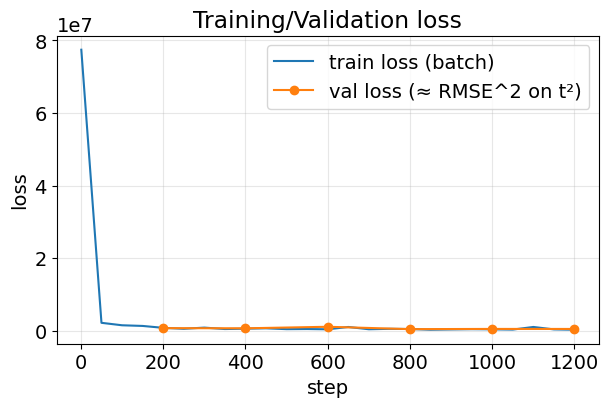

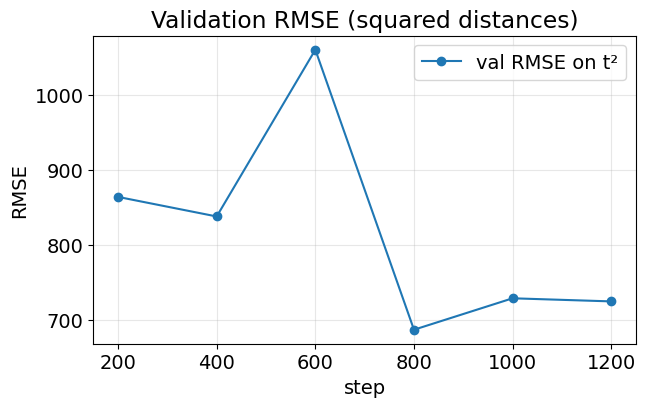

Best val RMSE=687.492955 at step=800
[LM] FINAL test: RMSE=693.367124 Pearson=0.9971 Spearman=0.9971


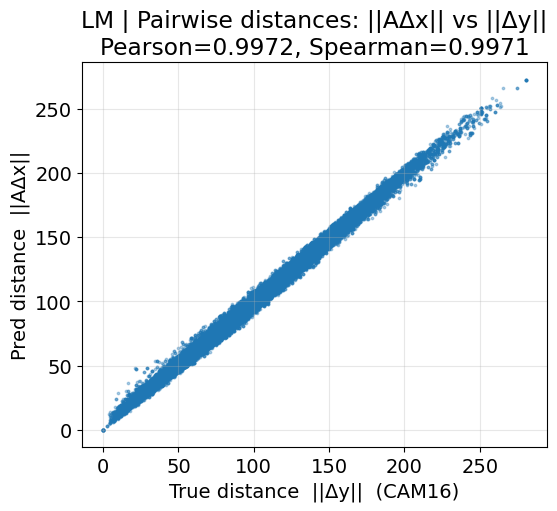

------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=200/1200 train_loss(batch)=2384020.000000 ||grad||=551036.312 ||A||=468.427
  [val] RMSE=1441.725399 Pearson=0.9879 Spearman=0.9853
step=400/1200 train_loss(batch)=1012061.625000 ||grad||=636207.750 ||A||=470.402
  [val] RMSE=993.234111 Pearson=0.9941 Spearman=0.9930
step=600/1200 train_loss(batch)=916341.562500 ||grad||=451564.188 ||A||=471.889
  [val] RMSE=812.473653 Pearson=0.9962 Spearman=0.9956
step=800/1200 train_loss(batch)=545050.375000 ||grad||=505208.594 ||A||=473.231
  [val] RMSE=706.197587 Pearson=0.9971 Spearman=0.9965
step=1000/1200 train_loss(batch)=500575.437500 ||grad||=946824.625 ||A||=474.325
  [val] RMSE=655.315287 Pearson=0.9974 Spearman=0.9968
step=1200/1200 train_loss(batch)=361798.562500 ||grad||=360636.562 ||A||=475.125
  [val] RMSE=609.327396 Pearson=0.9978 Spearman=0.9973


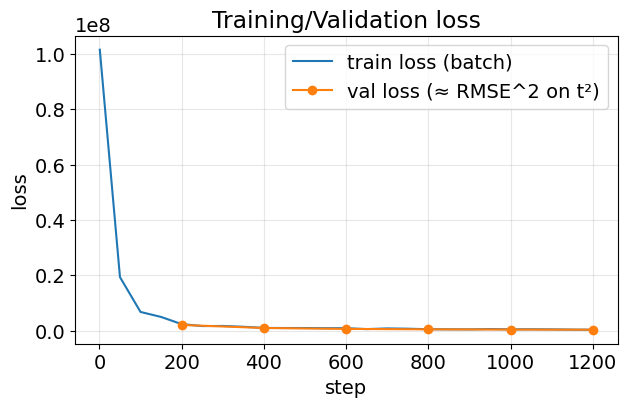

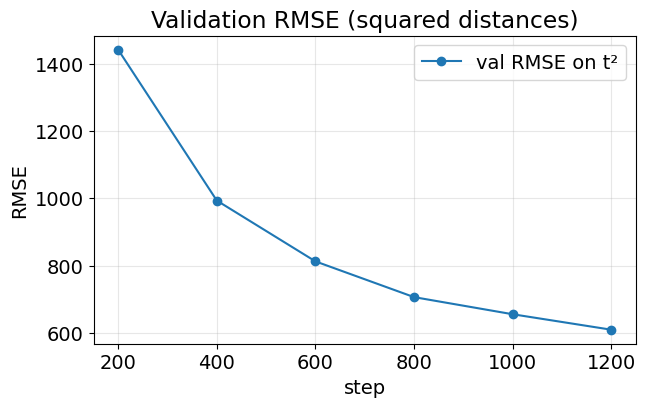

Best val RMSE=609.327396 at step=1200
[Vision] FINAL test: RMSE=613.910315 Pearson=0.9978 Spearman=0.9973


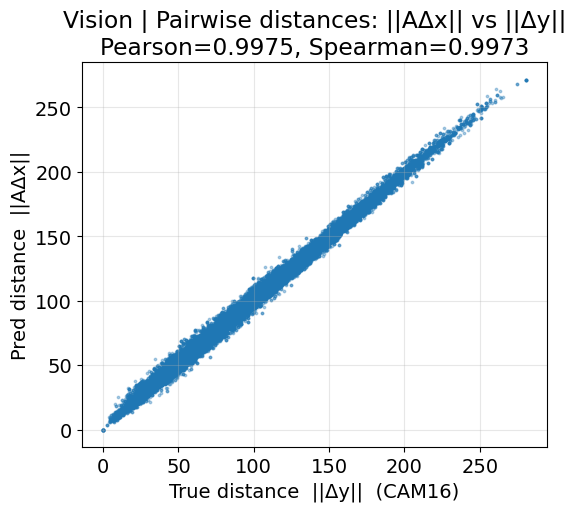

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V: (B,n)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2   (Y is 3D)
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


# ============================================================
# 1) Objective for FULL A (n x n)
#    L = mean ( ||A v||^2 - t2 )^2
#    grad_A = 4 * mean( e * (A v) v^T )
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1

        # decoupled weight decay
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Evaluation on held-out pairs
# ============================================================

def regression_errors(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs(y_pred - y_true) / denom) * 100.0)

    smape = float(
        np.mean(2.0 * np.abs(y_pred - y_true) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )

    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape}


def eval_alignment_fullA(X, Y, A, n_eval_pairs=80_000, seed=0, eps=1e-6, mode="sq"):
    """
    mode:
      "sq"   -> compare t2=||Δy||^2 with pred2=||AΔx||^2
      "dist" -> compare t =||Δy||   with pred =||AΔx||
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)

    # true
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t  = np.sqrt(np.maximum(t2, 0.0))

    # pred
    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred  = np.sqrt(np.maximum(pred2, 0.0))

    # select what to evaluate
    if mode == "sq":
        y_true, y_pred = t2, pred2
    elif mode == "dist":
        y_true, y_pred = t, pred
    else:
        raise ValueError("mode must be 'sq' or 'dist'")

    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]
    y_pred = y_pred[m]

    # errors
    errs = regression_errors(y_true, y_pred, eps=eps)

    # rank/linear correlations
    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    out = {**errs, "pearson": pr, "spearman": sr_r}
    return out



# ============================================================
# 4) Init: A = alpha * I (match mean squared distances roughly)
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop with validation + loss curves + early stopping
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,                 # how often to log train loss
    val_every=50,                # how often to evaluate validation
    n_val_pairs=80_000,
    # early stopping
    patience=5,
    min_delta=0.5,                # require improvement by at least min_delta
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    # init A = alpha I (or I if you prefer)
    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    # pre-sample training pairs
    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories for plots
    hist_step = []
    hist_train_loss = []
    hist_val_loss = []
    hist_val_rmse = []

    # best checkpoint
    best = {"val_rmse": np.inf, "A": A.copy(), "step": 0, "val_metrics": None}
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i = i_all[sl]
        j = j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(f"Non-finite at step={step}: loss={loss}, ||A||={np.linalg.norm(A)}")

        A = opt.step(A, grad.astype(np.float32))

        # log train loss (batch estimate)
        if step % log_every == 0 or step == 1:
            hist_step.append(step)
            hist_train_loss.append(loss)

        # validation
        if step % val_every == 0 or step == n_steps:
            val_sq = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step, mode="sq")
            val_d  = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 1, mode="dist")

            print(f"  [val sq]   RMSE={val_sq['rmse']:.3f} MAE={val_sq['mae']:.3f} "
                f"MAPE={val_sq['mape']:.2f}% sMAPE={val_sq['smape']:.2f}% "
                f"Pearson={val_sq['pearson']:.4f} Spearman={val_sq['spearman']:.4f}")

            print(f"  [val dist] RMSE={val_d['rmse']:.3f} MAE={val_d['mae']:.3f} "
                f"MAPE={val_d['mape']:.2f}% sMAPE={val_d['smape']:.2f}% "
                f"Pearson={val_d['pearson']:.4f} Spearman={val_d['spearman']:.4f}")

            val_rmse = val_sq['rmse']
            # early stopping on val_rmse
            if val_rmse < best["val_rmse"] - min_delta:
                best = {"val_rmse": val_rmse, "A": A.copy(), "step": step, "val_metrics": val_metrics}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: "
                          f"no improvement in val RMSE for {patience} validations. "
                          f"Best step={best['step']} val_RMSE={best['val_rmse']:.6f}")
                    break

    # --- plot curves ---
    # Align val points with their steps: every val_every
    val_steps = list(range(val_every, val_every * (len(hist_val_rmse)) + 1, val_every))
    if len(val_steps) != len(hist_val_rmse):
        # if last eval happened at n_steps not multiple of val_every
        val_steps = val_steps[:len(hist_val_rmse)]

    plt.figure(figsize=(7, 4))
    plt.plot(hist_step, hist_train_loss, label="train loss (batch)")
    if len(hist_val_loss) > 0:
        plt.plot(val_steps, hist_val_loss, marker="o", label="val loss (≈ RMSE^2 on t²)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training/Validation loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    if len(hist_val_rmse) > 0:
        plt.plot(val_steps, hist_val_rmse, marker="o", label="val RMSE on t²")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.title("Validation RMSE (squared distances)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Best val RMSE={best['val_rmse']:.6f} at step={best['step']}")
    return best, {
        "train_steps": np.array(hist_step),
        "train_loss": np.array(hist_train_loss),
        "val_steps": np.array(val_steps, dtype=int),
        "val_loss": np.array(hist_val_loss),
        "val_rmse": np.array(hist_val_rmse),
    }


def plot_distance_scatter(X, Y, A, n_plot_pairs=60_000, seed=123, title=""):
    """
    Plots distances (not squared):
        d_pred = ||AΔx||   vs   d_true = ||Δy||
    Uses sampled pairs.
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_plot_pairs, rng)

    # true distances
    dY = Y[i] - Y[j]
    d_true = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    # predicted distances
    dX = X[i] - X[j]
    AdX = dX @ A.T
    d_pred = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

    # correlation on distances (not squared)
    pr, _ = pearsonr(d_true, d_pred)
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    plt.figure(figsize=(6, 5))
    plt.scatter(d_true, d_pred, s=3, alpha=0.35)
    plt.xlabel("True distance  ||Δy||  (CAM16)")
    plt.ylabel("Pred distance  ||AΔx||")
    plt.title(title + f"\nPearson={pr:.4f}, Spearman={sr_r:.4f}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"pearson_dist": float(pr), "spearman_dist": float(sr_r)}

# ============================================================
# 6) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=200,
        n_val_pairs=80_000,
        patience=5,
        min_delta=0.0,
    )

    A_best = best["A"]
    final = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    print(f"[{layer_name}] FINAL test: RMSE={final['rmse']:.6f} Pearson={final['pearson']:.4f} Spearman={final['spearman']:.4f}")

    plot_distance_scatter(
        X_te, Y_te, A_best,
        n_plot_pairs=80_000,
        seed=777,
        title=f"{layer_name} | Pairwise distances: ||AΔx|| vs ||Δy||"
    )

    return {"A": A_best, "best": best, "final": final, "history": history}


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print('-' * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=200/1200 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val objective] loss=747253.062500
  [val sq]   RMSE=863.150 MAE=628.827 MAPE=10.65% sMAPE=9.06% Pearson=0.9961 Spearman=0.9956
  [val dist] RMSE=4.253 MAE=3.311 MAPE=4.89% sMAPE=4.57% Pearson=0.9959 Spearman=0.9956
step=400/1200 train_loss(batch)=602884.562500 ||grad||=9321348.000 ||A||=45.024
  [val objective] loss=702880.500000
  [val sq]   RMSE=836.488 MAE=544.004 MAPE=7.90% sMAPE=7.24% Pearson=0.9966 Spearman=0.9966
  [val dist] RMSE=3.584 MAE=2.740 MAPE=3.77% sMAPE=3.64% Pearson=0.9968 Spearman=0.9966
step=600/1200 train_loss(batch)=427571.937500 ||grad||=6862223.000 ||A||=45.176
  [val objective] loss=1124757.500000
  [val sq]   RMSE=1053.721 MAE=747.579 MAPE=10.81% sMAPE=9.61% Pearson=0.9941 Spearman=0.9950
  [val dist] RMSE=4.766 MAE=3.767 MAPE=5.10% sMAPE=4.83% Pearson=0.9950 Spearman=0.9950
step=

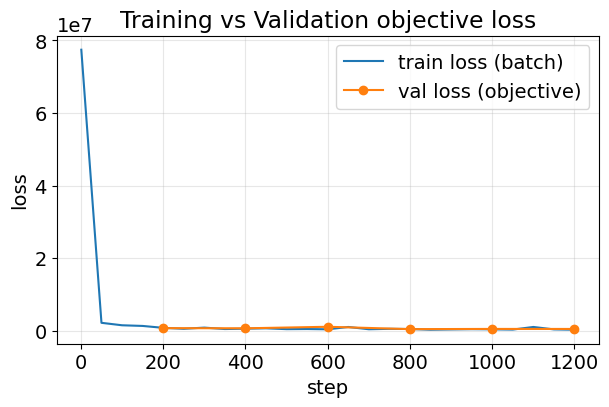

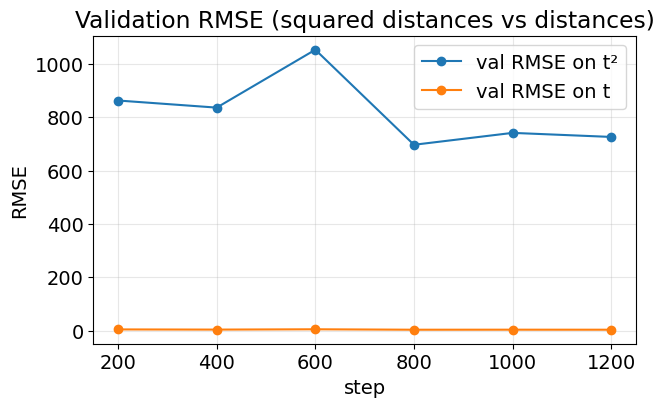

Best by VAL LOSS: step=800 val_loss=472646.562500
  [best val sq]   RMSE=697.066 MAE=487.956 MAPE=7.01% sMAPE=6.50% Pearson=0.9971 Spearman=0.9971
  [best val dist] RMSE=3.125 MAE=2.461 MAPE=3.35% sMAPE=3.25% Pearson=0.9973 Spearman=0.9971
[LM] FINAL test objective loss=480757.968750
[LM] FINAL test (sq):   RMSE=694.668 MAE=487.341 MAPE=7.03% sMAPE=6.53% Pearson=0.9971 Spearman=0.9971
[LM] FINAL test (dist): RMSE=3.143 MAE=2.472 MAPE=3.38% sMAPE=3.28% Pearson=0.9972 Spearman=0.9971


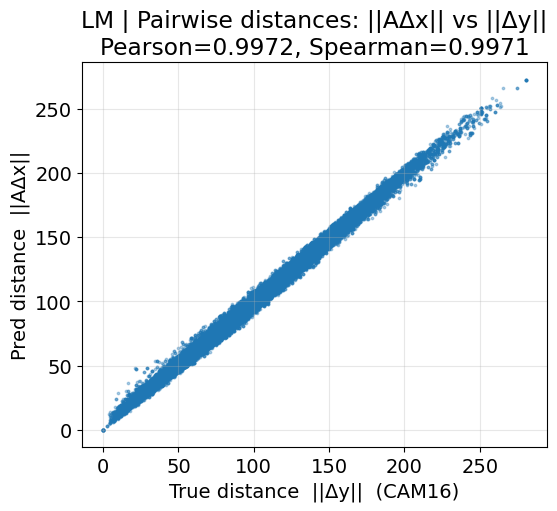

------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=200/1200 train_loss(batch)=2384020.000000 ||grad||=551036.312 ||A||=468.427
  [val objective] loss=2078572.125000
  [val sq]   RMSE=1448.155 MAE=1024.844 MAPE=15.92% sMAPE=13.85% Pearson=0.9879 Spearman=0.9852
  [val dist] RMSE=6.913 MAE=5.344 MAPE=7.38% sMAPE=6.98% Pearson=0.9869 Spearman=0.9851
step=400/1200 train_loss(batch)=1012061.625000 ||grad||=636207.750 ||A||=470.402
  [val objective] loss=986514.000000
  [val sq]   RMSE=992.070 MAE=707.475 MAPE=10.95% sMAPE=9.81% Pearson=0.9941 Spearman=0.9930
  [val dist] RMSE=4.812 MAE=3.698 MAPE=5.15% sMAPE=4.92% Pearson=0.9937 Spearman=0.9931
step=600/1200 train_loss(batch)=916341.562500 ||grad||=451564.188 ||A||=471.889
  [val objective] loss=660113.437500
  [val sq]   RMSE=809.970 MAE=572.937 MAPE=8.87% sMAPE=8.06% Pearson=0.9962 Spearman=0.9955
  [val dist] RMSE=3.897 MAE=2.980 MAPE=4.20% sMAPE=4.0

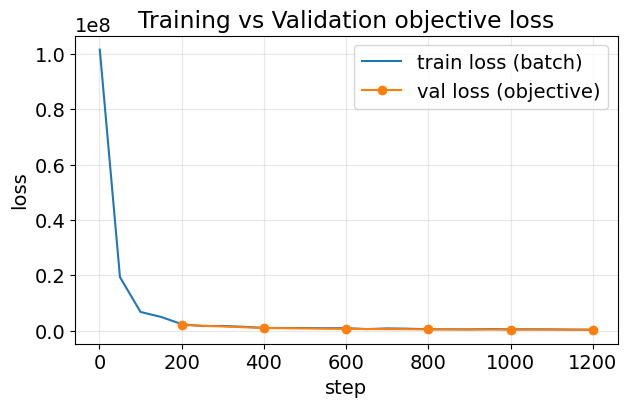

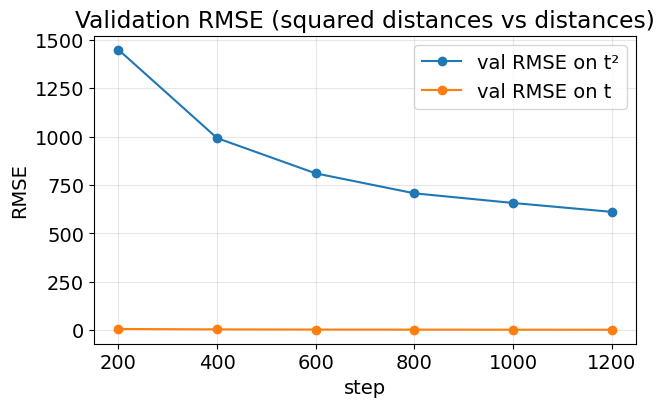

Best by VAL LOSS: step=1200 val_loss=371279.875000
  [best val sq]   RMSE=611.330 MAE=433.949 MAPE=6.62% sMAPE=6.19% Pearson=0.9978 Spearman=0.9973
  [best val dist] RMSE=3.004 MAE=2.283 MAPE=3.23% sMAPE=3.13% Pearson=0.9975 Spearman=0.9973
[Vision] FINAL test objective loss=376885.875000
[Vision] FINAL test (sq):   RMSE=609.760 MAE=432.920 MAPE=6.68% sMAPE=6.21% Pearson=0.9978 Spearman=0.9973
[Vision] FINAL test (dist): RMSE=2.995 MAE=2.278 MAPE=3.22% sMAPE=3.12% Pearson=0.9975 Spearman=0.9973


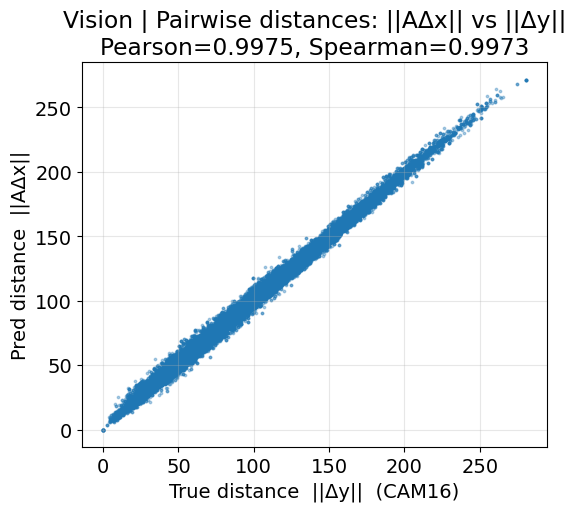

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V: (B,n)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2   (Y is 3D)
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2


# ============================================================
# 1) Objective for FULL A (n x n)
#    L = mean ( ||A v||^2 - t2 )^2
#    grad_A = 4 * mean( e * (A v) v^T )
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1

        # decoupled weight decay
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Validation metrics (MAE/MAPE/sMAPE) + correlations
# ============================================================

def regression_errors(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)

    smape = float(
        np.mean(2.0 * np.abs(err) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape}

def compute_pred_true_for_pairs(X, Y, A, i, j, eps=1e-12):
    """
    returns dict with arrays:
      t2, pred2, t, pred
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t2) & np.isfinite(pred2) & np.isfinite(t) & np.isfinite(pred)
    return {
        "t2": t2[m], "pred2": pred2[m],
        "t": t[m], "pred": pred[m]
    }

def eval_alignment_fullA(X, Y, A, n_eval_pairs=80_000, seed=0, eps=1e-6, mode="sq"):
    """
    mode:
      "sq"   -> compare t2=||Δy||^2 with pred2=||AΔx||^2
      "dist" -> compare t =||Δy||   with pred =||AΔx||
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d = compute_pred_true_for_pairs(X, Y, A, i, j)

    if mode == "sq":
        y_true, y_pred = d["t2"], d["pred2"]
    elif mode == "dist":
        y_true, y_pred = d["t"], d["pred"]
    else:
        raise ValueError("mode must be 'sq' or 'dist'")

    errs = regression_errors(y_true, y_pred, eps=eps)

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {**errs, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Validation loss in the SAME objective units as training:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))


# ============================================================
# 4) Init: A = alpha * I (match mean squared distances roughly)
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop with validation metrics, BUT best step by VAL LOSS
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    # logging
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    # early stopping by val loss (objective)
    patience=5,
    min_delta=0.0,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_sq_rmse, hist_val_dist_rmse = [], []

    # best checkpoint by VAL LOSS (objective units)
    best = {
        "val_loss": np.inf,
        "A": A.copy(),
        "step": 0,
        "val_metrics_sq": None,
        "val_metrics_dist": None,
    }
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            # --- Val loss (objective) ---
            val_loss = estimate_val_loss_sq(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step)

            # --- Extra metrics (sq + dist) ---
            val_sq = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 10, mode="sq")
            val_d  = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11, mode="dist")

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_sq_rmse.append(val_sq["rmse"])
            hist_val_dist_rmse.append(val_d["rmse"])

            print(f"step={step}/{n_steps} "
                  f"train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")

            print(f"  [val sq]   RMSE={val_sq['rmse']:.3f} MAE={val_sq['mae']:.3f} "
                  f"MAPE={val_sq['mape']:.2f}% sMAPE={val_sq['smape']:.2f}% "
                  f"Pearson={val_sq['pearson']:.4f} Spearman={val_sq['spearman']:.4f}")

            print(f"  [val dist] RMSE={val_d['rmse']:.3f} MAE={val_d['mae']:.3f} "
                  f"MAPE={val_d['mape']:.2f}% sMAPE={val_d['smape']:.2f}% "
                  f"Pearson={val_d['pearson']:.4f} Spearman={val_d['spearman']:.4f}")

            # --- early stopping & best checkpoint by val_loss ---
            if val_loss < best["val_loss"] - min_delta:
                best = {
                    "val_loss": val_loss,
                    "A": A.copy(),
                    "step": step,
                    "val_metrics_sq": val_sq,
                    "val_metrics_dist": val_d,
                }
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: "
                          f"no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---- plots ----
    plt.figure(figsize=(7, 4))
    plt.plot(hist_train_steps, hist_train_loss, label="train loss (batch)")
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_loss, marker="o", label="val loss (objective)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training vs Validation objective loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_sq_rmse, marker="o", label="val RMSE on t²")
        plt.plot(hist_val_steps, hist_val_dist_rmse, marker="o", label="val RMSE on t")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.title("Validation RMSE (squared distances vs distances)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_metrics_sq"] is not None:
        sq = best["val_metrics_sq"]
        d = best["val_metrics_dist"]
        print(f"  [best val sq]   RMSE={sq['rmse']:.3f} MAE={sq['mae']:.3f} MAPE={sq['mape']:.2f}% sMAPE={sq['smape']:.2f}% "
              f"Pearson={sq['pearson']:.4f} Spearman={sq['spearman']:.4f}")
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": np.array(hist_train_steps, dtype=int),
        "train_loss": np.array(hist_train_loss, dtype=float),
        "val_steps": np.array(hist_val_steps, dtype=int),
        "val_loss": np.array(hist_val_loss, dtype=float),
        "val_sq_rmse": np.array(hist_val_sq_rmse, dtype=float),
        "val_dist_rmse": np.array(hist_val_dist_rmse, dtype=float),
    }
    return best, history


# ============================================================
# 6) Scatter plot: ||AΔx|| vs ||Δy||
# ============================================================

def plot_distance_scatter(X, Y, A, n_plot_pairs=60_000, seed=123, title=""):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_plot_pairs, rng)

    dY = Y[i] - Y[j]
    d_true = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    d_pred = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    plt.figure(figsize=(6, 5))
    plt.scatter(d_true, d_pred, s=3, alpha=0.35)
    plt.xlabel("True distance  ||Δy||  (CAM16)")
    plt.ylabel("Pred distance  ||AΔx||")
    plt.title(title + f"\nPearson={pr:.4f}, Spearman={sr_r:.4f}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"pearson_dist": pr, "spearman_dist": sr_r}


# ============================================================
# 7) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
    )

    A_best = best["A"]

    # FINAL evaluation on test, using additional metrics (but not for selection)
    final_loss = estimate_val_loss_sq(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_sq = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1001, mode="sq")
    final_d  = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002, mode="dist")

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test (sq):   RMSE={final_sq['rmse']:.3f} MAE={final_sq['mae']:.3f} "
          f"MAPE={final_sq['mape']:.2f}% sMAPE={final_sq['smape']:.2f}% "
          f"Pearson={final_sq['pearson']:.4f} Spearman={final_sq['spearman']:.4f}")
    print(f"[{layer_name}] FINAL test (dist): RMSE={final_d['rmse']:.3f} MAE={final_d['mae']:.3f} "
          f"MAPE={final_d['mape']:.2f}% sMAPE={final_d['smape']:.2f}% "
          f"Pearson={final_d['pearson']:.4f} Spearman={final_d['spearman']:.4f}")

    plot_distance_scatter(
        X_te, Y_te, A_best,
        n_plot_pairs=80_000,
        seed=777,
        title=f"{layer_name} | Pairwise distances: ||AΔx|| vs ||Δy||"
    )

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "sq": final_sq, "dist": final_d},
    }


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=50/1500 train_loss(batch)=2214018.500000 ||grad||=20350154.000 ||A||=44.598
  [val objective] loss=1582794.000000
  [val dist] RMSE=6.109 MAE=4.717 MAPE=6.98% sMAPE=6.42% Pearson=0.9907 Spearman=0.9901
step=100/1500 train_loss(batch)=1537622.875000 ||grad||=18037188.000 ||A||=44.703
  [val objective] loss=1154271.750000
  [val dist] RMSE=4.950 MAE=3.868 MAPE=5.59% sMAPE=5.23% Pearson=0.9937 Spearman=0.9932
step=150/1500 train_loss(batch)=1355572.375000 ||grad||=15114224.000 ||A||=44.781
  [val objective] loss=885718.625000
  [val dist] RMSE=4.493 MAE=3.473 MAPE=5.20% sMAPE=4.84% Pearson=0.9955 Spearman=0.9953
step=200/1500 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val objective] loss=747253.062500
  [val dist] RMSE=4.253 MAE=3.311 MAPE=4.89% sMAPE=4.57% Pearson=0.9959 Spearman=0.9956
step=250/1500 train_loss(batch)=570257.125000 ||grad||=10060398.000 ||A||

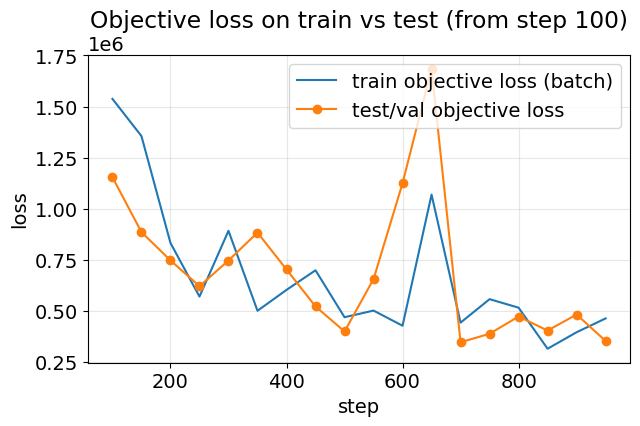

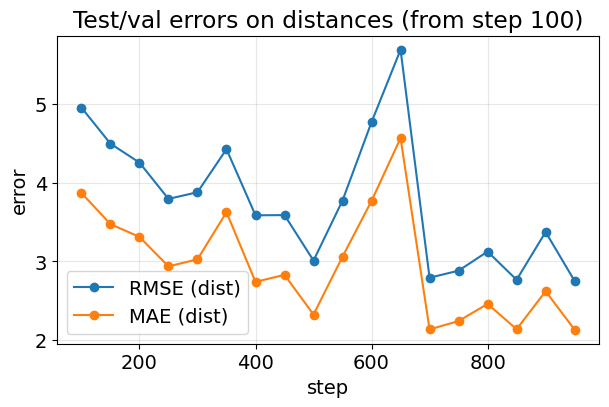

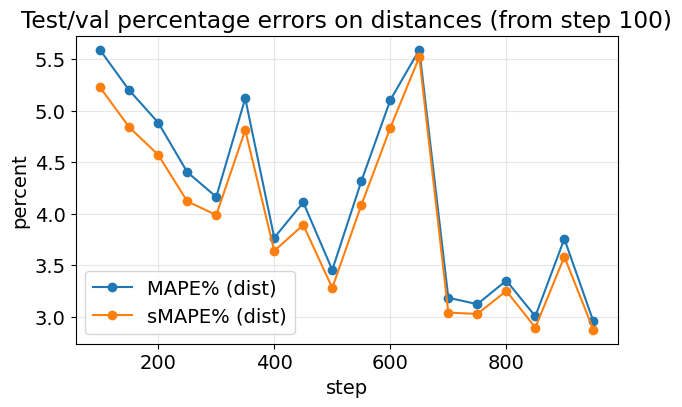

Best by VAL LOSS: step=700 val_loss=346588.812500
  [best val dist] RMSE=2.793 MAE=2.138 MAPE=3.18% sMAPE=3.04% Pearson=0.9980 Spearman=0.9979
[LM] FINAL test objective loss=344291.968750
[LM] FINAL test distances: RMSE=2.773 MAE=2.131 MAPE=3.16% sMAPE=3.02% Pearson=0.9980 Spearman=0.9979
------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=50/1500 train_loss(batch)=19360168.000000 ||grad||=2018502.250 ||A||=464.521
  [val objective] loss=16968128.000000
  [val dist] RMSE=16.971 MAE=13.156 MAPE=17.31% sMAPE=15.21% Pearson=0.9250 Spearman=0.9321
step=100/1500 train_loss(batch)=6777116.000000 ||grad||=1500686.375 ||A||=466.274
  [val objective] loss=5601024.000000
  [val dist] RMSE=10.212 MAE=7.861 MAPE=10.68% sMAPE=9.75% Pearson=0.9741 Spearman=0.9739
step=150/1500 train_loss(batch)=4975395.500000 ||grad||=909641.938 ||A||=467.533
  [val objective] loss=2969081.750000
  [val dist] RMSE=7.760 MAE=5.969

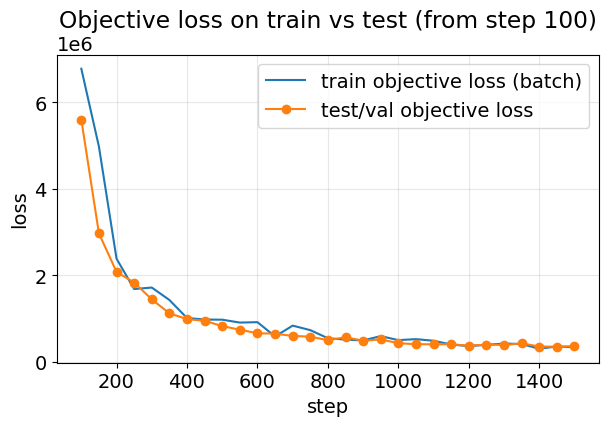

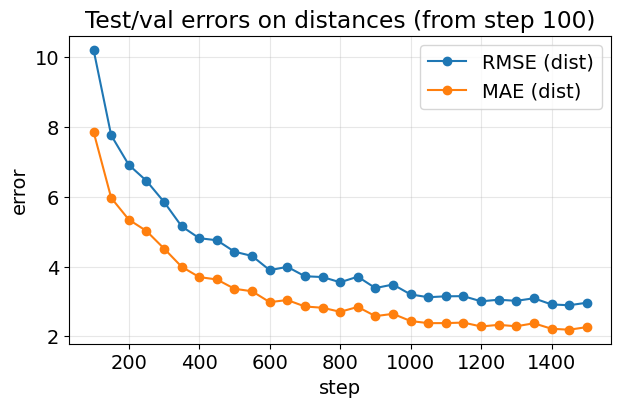

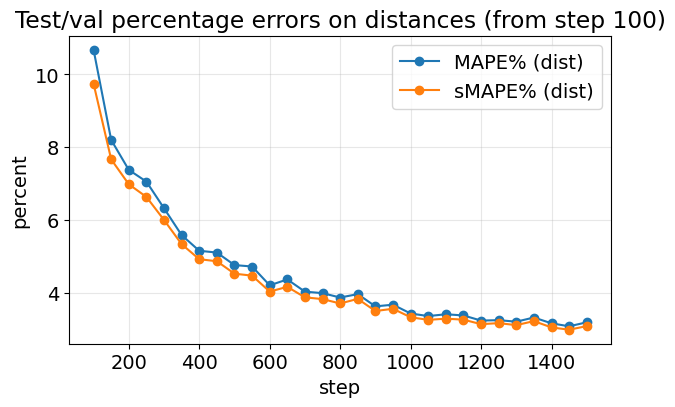

Best by VAL LOSS: step=1450 val_loss=350019.062500
  [best val dist] RMSE=2.892 MAE=2.190 MAPE=3.07% sMAPE=2.98% Pearson=0.9977 Spearman=0.9976
[Vision] FINAL test objective loss=348335.562500
[Vision] FINAL test distances: RMSE=2.871 MAE=2.174 MAPE=3.08% sMAPE=2.98% Pearson=0.9978 Spearman=0.9976


In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V:  (B,n) = X[i]-X[j]
      t2: (B,)  = ||Y[i]-Y[j]||^2
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2

def compute_pred_true_for_pairs(X, Y, A, i, j):
    """
    returns arrays:
      t  = ||Δy||,  pred = ||AΔx||
      t2 = ||Δy||^2, pred2=||AΔx||^2
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) Objective for FULL A (n x n): squared-distances objective
#    L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES (not squared)
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq_objective(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Objective loss in training units:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))

def eval_dist_metrics(X, Y, A, n_eval_pairs=80_000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d_true, d_pred, _, _ = compute_pred_true_for_pairs(X, Y, A, i, j)
    return dist_errors(d_true, d_pred)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop
#    - best step by VAL objective loss
#    - plots:
#        (a) train vs val objective loss (from plot_from_step)
#        (b) distance metrics (RMSE/MAE/MAPE/sMAPE) on val (from plot_from_step)
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []

    # distance metrics histories (val only)
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step
            )
            val_dist = eval_dist_metrics(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)

            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(f"  [val dist] RMSE={val_dist['rmse']:.3f} MAE={val_dist['mae']:.3f} "
                  f"MAPE={val_dist['mape']:.2f}% sMAPE={val_dist['smape']:.2f}% "
                  f"Pearson={val_dist['pearson']:.4f} Spearman={val_dist['spearman']:.4f}")

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---------- plots ----------
    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    # NEW: train + test(=val) objective loss on one plot
    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="test/val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs test (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # distance metrics (only distances)
    if len(hist_val_steps) > 0:
        m_va = va_s >= plot_from_step
        if m_va.any():
            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
            plt.xlabel("step")
            plt.ylabel("error")
            plt.title(f"Test/val errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
            plt.xlabel("step")
            plt.ylabel("percent")
            plt.title(f"Test/val percentage errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} "
              f"MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_dist = eval_dist_metrics(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002)

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test distances: "
          f"RMSE={final_dist['rmse']:.3f} MAE={final_dist['mae']:.3f} "
          f"MAPE={final_dist['mape']:.2f}% sMAPE={final_dist['smape']:.2f}% "
          f"Pearson={final_dist['pearson']:.4f} Spearman={final_dist['spearman']:.4f}")

    return {"A": A_best, "best": best, "history": history, "final": {"loss": final_loss, "dist": final_dist}}


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


In [30]:
from vsl_ial.vsl_ial.stress import stress, mean_stress, group_stress
import numpy as np

def build_pair_indices(n, max_pairs=None, seed=42):
    i_all, j_all = np.triu_indices(n, k=1)
    if max_pairs is not None and max_pairs < i_all.size:
        rng = np.random.default_rng(seed)
        sel = rng.choice(i_all.size, size=max_pairs, replace=False)
        i_all, j_all = i_all[sel], j_all[sel]
    return i_all, j_all

def pairwise_distance_arrays(X, Y, A, pair_idx=None, chunk_size=20_000):
    """
    d_emb_A = ||A(x_i - x_j)||
    d_cam   = ||y_i - y_j||
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    A = np.asarray(A, dtype=np.float64)

    n = X.shape[0]
    if pair_idx is None:
        i_all, j_all = np.triu_indices(n, k=1)
    else:
        i_all, j_all = pair_idx
        # safety
        if i_all.max() >= n or j_all.max() >= n:
            raise ValueError(f"pair_idx out of bounds: max_i={i_all.max()}, max_j={j_all.max()}, n={n}")

    d_emb_A = np.empty(i_all.shape[0], dtype=np.float64)
    d_cam   = np.empty(i_all.shape[0], dtype=np.float64)

    for s in range(0, i_all.shape[0], chunk_size):
        e = min(s + chunk_size, i_all.shape[0])
        i, j = i_all[s:e], j_all[s:e]

        dX  = X[i] - X[j]
        AdX = dX @ A.T
        d_emb_A[s:e] = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

        dY = Y[i] - Y[j]
        d_cam[s:e] = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    m = np.isfinite(d_emb_A) & np.isfinite(d_cam)
    return d_emb_A[m], d_cam[m]

X_lm, Y_cam_lm = sanitize_XY(lm, cam)
X_vl, Y_cam_vl = sanitize_XY(vl, cam)

assert X_lm.shape[0] == X_vl.shape[0] == Y_cam_lm.shape[0] == Y_cam_vl.shape[0], \
    (X_lm.shape, X_vl.shape, Y_cam_lm.shape, Y_cam_vl.shape)

n = Y_cam_lm.shape[0]
pair_idx = build_pair_indices(n=n, max_pairs=None, seed=42)  

d_emb_A_lm, d_cam = pairwise_distance_arrays(X_lm, Y_cam_lm, out_lm["A"], pair_idx=pair_idx)
d_emb_A_vl, _     = pairwise_distance_arrays(X_vl, Y_cam_vl, out_vl["A"], pair_idx=pair_idx)

print(f"Stress LM (ord=2):     {stress(d_emb_A_lm, d_cam, ord=2):.6f}")
print(f"Stress Vision (ord=2): {stress(d_emb_A_vl, d_cam, ord=2):.6f}")


Stress LM (ord=2):     0.026299
Stress Vision (ord=2): 0.026517
